# PCA-AE architecture and validation study

This notebook studies the additive frozen rank-30 PCA plus nonlinear coefficient autoencoder. Every positive $A_\theta(k,z)$ surface is represented in $\log_{10}$ space on the fixed $(31,101)$ redshift--wavenumber grid. The fixed PCA map reduces 3,131 surface values to 30 coefficients; a fully connected autoencoder then compresses those coefficients through the sampled latent dimensions.

All scientific comparisons use authenticated complete-validation artifacts selected by `ModelSelection.ipynb`. The notebook does not train a model, run inference, read training or test surface samples, evaluate test performance, or select a winner across PCA-AE, Conv1D, and Conv2D. Stored training latent coordinates are read only to define the selected latent standardization; test latents remain closed. Missing nonselected configurations remain explicit and are never imputed.


In [1]:
import csv
import json
import math
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", message="IProgress not found.*")


In [2]:
import h5py
import numpy as np
import torch
from IPython.display import Markdown, display
from matplotlib import pyplot as plt


In [3]:
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "pyproject.toml").is_file():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Run this notebook from within IAFlowCloud.")
    PROJECT_ROOT = PROJECT_ROOT.parent

CODE_PATH = PROJECT_ROOT / "Code"
if str(CODE_PATH) not in sys.path:
    sys.path.insert(0, str(CODE_PATH))


In [4]:
from iaflow.comparison import (
    audit_compressor_runs,
    compressor_selection_input_sha256,
    notebook_source_sha256,
)
from iaflow.pca_autoencoder.config import (
    load_pca_ae_experiment_template,
    load_resolved_pca_ae_config,
)
from iaflow.pca_autoencoder.data import load_pca_ae_transform
from iaflow.pca_autoencoder.transform import file_sha256
from iaflow.validation_visuals import (
    DEPTH_LINESTYLES,
    DEPTH_MARKERS,
    FAMILY_COLORS,
    FIGURE_SIZES,
    METRIC_PRESENTATION,
    SELECTION_MARKERS,
    apply_validation_style,
    empirical_survival,
    plot_validation_metric_panel,
    positive_log_limits,
    safe_pearson_correlation,
    save_validation_figure,
    selection_legend_handles,
    shared_positive_log_norm,
)

DEPTHS = ("Depth03", "Depth04", "Depth05")
LATENT_DIMENSIONS = (2, 4, 6, 8, 10)
EXPECTED_PCA_RANK = 30
TARGET_VARIANCE_RECOVERED = 0.999
EXPECTED_TRAINING_SAMPLES = 80000
EXPECTED_VALIDATION_SAMPLES = 10000
SELECTION_MANIFEST_PATH = (
    PROJECT_ROOT
    / "Data"
    / "NLA"
    / "Comparison"
    / "ValidationSelectionLive.json"
)

FIGURE_DIRECTORY = PROJECT_ROOT / "Figure" / "NLA" / "PCA_AE"
GENERATED_FIGURES = []
apply_validation_style()

print("Project:", PROJECT_ROOT)
print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)
print("h5py:", h5py.__version__)


Project: /Users/s2227120/IAFlowCloud
Python: 3.12.13
NumPy: 2.0.2
PyTorch: 2.10.0
h5py: 3.15.1


## 1. Method and comparison contract

The tensor flow is

$$
(31,101)\rightarrow3131\rightarrow30
\rightarrow L\rightarrow30\rightarrow3131\rightarrow(31,101).
$$

Three different quantities must not be conflated:

- **matched rank-$L$ PCA** is the linear validation comparator at the same compressed dimension;
- **rank-30 PCA** is the fixed front end and inverse map used inside every PCA-AE;
- the PCA-AE surface error is the sum of the learned coefficient-reconstruction contribution and the irreducible rank-30 projection floor.


In [5]:
def read_json(
    path,
):
    """
    Read one required JSON mapping.
    
    Arguments:
        path (pathlib.Path):
            JSON artifact to read.
    
    Returns:
        values (dict):
            Parsed JSON mapping.
    """
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(f"Missing required JSON artifact: {path}")
    with path.open("r", encoding="utf-8") as stream:
        values = json.load(stream)
    if not isinstance(values, dict):
        raise ValueError(f"Expected a JSON mapping: {path}")
    return values


def require_keys(
    values,
    required_keys,
    label,
):
    """
    Require named fields in one mapping.
    
    Arguments:
        values (dict):
            Mapping to validate.
        required_keys (tuple[str, ...]):
            Fields that must be present.
        label (str):
            Human-readable mapping name used in failures.
    """
    if not isinstance(values, dict):
        raise TypeError(f"{label} must be a mapping.")
    missing = [name for name in required_keys if name not in values]
    if missing:
        raise KeyError(f"{label} is missing required fields: {missing}")


def resolve_project_path(
    relative_path,
    label,
):
    """
    Resolve one required project-relative path without allowing escape.
    
    Arguments:
        relative_path (str):
            Path recorded relative to the project root.
        label (str):
            Human-readable artifact name used in failures.
    
    Returns:
        path (pathlib.Path):
            Existing path resolved inside the project root.
    """
    relative_path = Path(relative_path)
    if relative_path.is_absolute():
        raise ValueError(f"{label} must be project relative.")
    path = (PROJECT_ROOT / relative_path).resolve()
    try:
        path.relative_to(PROJECT_ROOT)
    except ValueError as error:
        raise ValueError(f"{label} escapes the project root.") from error
    if not path.exists():
        raise FileNotFoundError(f"Missing {label}: {path}")
    return path


def authenticate_file(
    path,
    expected_sha256,
    label,
):
    """
    Authenticate one file against a recorded SHA-256 digest.
    
    Arguments:
        path (pathlib.Path):
            Existing file to hash.
        expected_sha256 (str):
            Expected lowercase hexadecimal SHA-256 digest.
        label (str):
            Human-readable artifact name used in failures.
    """
    expected_sha256 = str(expected_sha256)
    if len(expected_sha256) != 64 or any(
        character not in "0123456789abcdef" for character in expected_sha256
    ):
        raise ValueError(f"{label} has an invalid SHA-256 digest.")
    observed_sha256 = file_sha256(path)
    if observed_sha256 != expected_sha256:
        raise RuntimeError(
            f"{label} changed after model selection; rerun ModelSelection.ipynb."
        )


def read_csv_rows(
    path,
):
    """
    Read one CSV table as string-valued row mappings.
    
    Arguments:
        path (pathlib.Path):
            CSV table to read.
    
    Returns:
        rows (list[dict[str, str]]):
            Ordered table rows.
    """
    with Path(path).open("r", encoding="utf-8", newline="") as stream:
        reader = csv.DictReader(stream)
        if reader.fieldnames is None:
            raise ValueError(f"CSV table has no header: {path}")
        rows = list(reader)
    if not rows:
        raise ValueError(f"CSV table has no rows: {path}")
    return rows


def parse_pca_ae_cell_id(
    cell_id,
):
    """
    Parse and validate one PCA-AE configuration identifier.
    
    Arguments:
        cell_id (str):
            Identifier in family, architecture, depth, and latent form.
    
    Returns:
        key (tuple[str, int]):
            Depth label and latent dimension.
    """
    fields = str(cell_id).split(":")
    if len(fields) != 4 or fields[:2] != ["PCA_AE", "PCA_AE"]:
        raise ValueError(f"Not a PCA-AE cell identifier: {cell_id}")
    depth = fields[2]
    latent_label = fields[3]
    if depth not in DEPTHS or not latent_label.startswith("L"):
        raise ValueError(f"Invalid PCA-AE cell identifier: {cell_id}")
    latent_dim = int(latent_label[1:])
    if latent_dim not in LATENT_DIMENSIONS:
        raise ValueError(f"Unsupported PCA-AE latent dimension: {cell_id}")
    return depth, latent_dim


def display_markdown_table(
    headers,
    rows,
):
    """
    Display a compact Markdown table without a pandas dependency.
    
    Arguments:
        headers (tuple[str, ...]):
            Ordered column headings.
        rows (list[tuple[object, ...]]):
            Ordered table rows.
    """
    if any(len(row) != len(headers) for row in rows):
        raise ValueError("Every Markdown table row must match the headers.")
    def clean(value):
        return str(value).replace("|", "\\|").replace("\n", " ")
    lines = [
        "| " + " | ".join(clean(value) for value in headers) + " |",
        "| " + " | ".join("---" for _ in headers) + " |",
    ]
    lines.extend(
        "| " + " | ".join(clean(value) for value in row) + " |"
        for row in rows
    )
    display(Markdown("\n".join(lines)))


def save_figure(
    figure,
    filename,
):
    """
    Save, register, display, and close one PCA-AE PDF figure.
    
    Arguments:
        figure (matplotlib.figure.Figure):
            Completed Matplotlib figure.
        filename (str):
            PDF filename within Figure/NLA/PCA_AE.
    
    Returns:
        path (pathlib.Path):
            Existing non-empty PDF figure path.
    """
    path = FIGURE_DIRECTORY / filename
    save_validation_figure(
        figure,
        path,
        creator="Notebooks/NLA/PCA_AE.ipynb",
    )
    GENERATED_FIGURES.append(path)
    plt.show()
    plt.close(figure)
    return path


def parse_csv_boolean(
    value,
    label,
):
    """
    Parse one strict boolean written by csv.DictWriter.
    
    Arguments:
        value (str):
            CSV field containing exactly True or False.
        label (str):
            Field name used in validation failures.
    
    Returns:
        parsed (bool):
            Parsed boolean value.
    """
    if value == "True":
        return True
    if value == "False":
        return False
    raise ValueError(f"{label} must contain True or False.")


def audit_csv_projection(
    audit,
    fieldnames,
):
    """
    Serialize one live audit into the authenticated CSV representation.
    
    Arguments:
        audit (dict):
            Live record returned by audit_compressor_runs.
        fieldnames (tuple[str, ...]):
            Ordered audit-table field names.
    
    Returns:
        projected (dict[str, str]):
            String-valued record matching csv.DictReader output.
    """
    projected = {}
    for name in fieldnames:
        value = audit[name]
        if name in {"exclusion_reasons", "warnings"}:
            projected[name] = json.dumps(value)
        elif value is None:
            projected[name] = ""
        else:
            projected[name] = str(value)
    return projected


def selected_figure_title(
    diagnostic,
):
    """
    Build the common provisional selected-model figure title.
    
    Arguments:
        diagnostic (str):
            Short description of the displayed diagnostic.
    
    Returns:
        title (str):
            Two-line selection and validation-boundary title.
    """
    return (
        "Selected minimum-adequate PCA-AE, "
        f"{selected_diagnostic_key[0]}, L={selected_diagnostic_key[1]}: "
        f"{diagnostic}\n"
        f"Validation only; seed {selected_diagnostic_run['seed']}; "
        "selection provisional"
    )


def dense_stack_parameter_count(
    input_features,
    hidden_features,
    output_features,
):
    """
    Count Linear-layer weights and biases in one dense stack.
    
    Arguments:
        input_features (int):
            Input width.
        hidden_features (tuple[int, ...]):
            Hidden widths in order.
        output_features (int):
            Output width.
    
    Returns:
        count (int):
            Number of learned scalar parameters.
    """
    widths = (int(input_features), *tuple(hidden_features), int(output_features))
    return sum(
        input_width * output_width + output_width
        for input_width, output_width in zip(widths[:-1], widths[1:])
    )


def best_history_record(
    history,
    best_epoch,
):
    """
    Return the unique history record for a selected epoch.
    
    Arguments:
        history (list[dict]):
            Complete stored training history.
        best_epoch (int):
            Validation-selected checkpoint epoch.
    
    Returns:
        record (dict):
            Unique matching history record.
    """
    matches = [row for row in history if int(row["epoch"]) == int(best_epoch)]
    if len(matches) != 1:
        raise ValueError(f"Expected one history row for epoch {best_epoch}.")
    return matches[0]


## 2. Authenticate the live selection and frozen PCA provenance

`ModelSelection.ipynb` is the sole selection authority. This notebook requires its current validation-only manifest, authenticates the referenced tables and PCA artifacts, recomputes the live selection-input fingerprint, and stops if any candidate or selected diagnostic artifact has changed. There is no hard-coded fallback model.

The three depth templates must also point to the same non-whitened rank-30 transform, source surface cache, coefficient cache, and validation benchmark. These checks use stored provenance and numerical transform metadata; they do not inspect training or test samples.


In [6]:
selection_manifest = read_json(SELECTION_MANIFEST_PATH)
require_keys(
    selection_manifest,
    (
        "kind",
        "status",
        "git",
        "selection_scope",
        "policy",
        "coverage",
        "inputs",
        "tables",
        "selections",
        "diagnostic_runs",
        "test_gate",
    ),
    "live selection manifest",
)
if selection_manifest["kind"] != "validation_selection_live":
    raise ValueError("Unexpected selection-manifest kind.")
if selection_manifest["status"] != "provisional_validation":
    raise RuntimeError("PCA-AE analysis requires a provisional validation manifest.")
if selection_manifest["selection_scope"] != [
    "PCA_AE",
    "Conv1D",
    "Conv2D",
]:
    raise ValueError("Unexpected model-selection scope.")

test_gate = selection_manifest["test_gate"]
require_keys(
    test_gate,
    ("selection_frozen", "test_evaluation_allowed"),
    "test gate",
)
if test_gate["selection_frozen"] or test_gate["test_evaluation_allowed"]:
    raise RuntimeError("This notebook is restricted to the open validation gate.")

manifest_inputs = selection_manifest["inputs"]
require_keys(
    manifest_inputs,
    (
        "selection_input_sha256",
        "selection_notebook",
        "pca_metrics",
        "pca_metadata",
    ),
    "selection inputs",
)
require_keys(
    manifest_inputs["selection_notebook"],
    ("path", "source_sha256"),
    "selection notebook",
)
selection_notebook_path = resolve_project_path(
    manifest_inputs["selection_notebook"]["path"],
    "selection notebook",
)
if notebook_source_sha256(selection_notebook_path) != manifest_inputs[
    "selection_notebook"
]["source_sha256"]:
    raise RuntimeError(
        "ModelSelection sources changed; rerun it before PCA_AE.ipynb."
    )
for name in ("pca_metrics", "pca_metadata"):
    require_keys(manifest_inputs[name], ("path", "sha256"), name)
pca_metrics_path = resolve_project_path(
    manifest_inputs["pca_metrics"]["path"],
    "PCA validation metrics",
)
pca_transform_metadata_path = resolve_project_path(
    manifest_inputs["pca_metadata"]["path"],
    "PCA transform metadata",
)
authenticate_file(
    pca_metrics_path,
    manifest_inputs["pca_metrics"]["sha256"],
    "PCA validation metrics",
)
authenticate_file(
    pca_transform_metadata_path,
    manifest_inputs["pca_metadata"]["sha256"],
    "PCA transform metadata",
)

manifest_tables = selection_manifest["tables"]
require_keys(manifest_tables, ("results", "audit"), "selection tables")
table_paths = {}
for name in ("results", "audit"):
    require_keys(manifest_tables[name], ("path", "sha256"), f"{name} table")
    table_paths[name] = resolve_project_path(
        manifest_tables[name]["path"],
        f"selection {name} table",
    )
    authenticate_file(
        table_paths[name],
        manifest_tables[name]["sha256"],
        f"selection {name} table",
    )
RESULT_TABLE_ROWS = read_csv_rows(table_paths["results"])
AUDIT_TABLE_ROWS = read_csv_rows(table_paths["audit"])
RESULT_ROWS_BY_CELL = {row["cell_id"]: row for row in RESULT_TABLE_ROWS}
if len(RESULT_ROWS_BY_CELL) != len(RESULT_TABLE_ROWS):
    raise ValueError("The validation result table contains duplicate cells.")

policy = selection_manifest["policy"]
require_keys(
    policy,
    (
        "diagnostic_role",
        "latent_dimensions",
        "minimum_variance_recovered",
        "require_matched_pca_outperformance",
        "replicates",
        "minimum_adequate_order",
        "best_accuracy_order",
    ),
    "selection policy",
)
if tuple(policy["latent_dimensions"]) != LATENT_DIMENSIONS:
    raise RuntimeError("The manifest uses different latent dimensions.")
if policy["diagnostic_role"] != "family_minimum_adequate":
    raise RuntimeError("Unsupported PCA-AE diagnostic-selection role.")
if not policy["require_matched_pca_outperformance"]:
    raise RuntimeError("Matched-PCA outperformance must remain an adequacy gate.")
require_keys(
    policy["replicates"],
    (
        "aggregate",
        "diagnostic_replicate",
        "duplicate_seed_policy",
        "outperformance_gate",
        "required_seeds",
    ),
    "selection-policy replicates",
)
if policy["replicates"]["aggregate"] != "median":
    raise RuntimeError("PCA-AE analysis requires median replicate aggregation.")
if policy["replicates"]["required_seeds"] != [42]:
    raise RuntimeError("The required validation seed set changed.")
if policy["replicates"]["outperformance_gate"] != "all_required_seeds":
    raise RuntimeError("The matched-PCA replicate gate changed.")
if not np.isclose(
    float(policy["minimum_variance_recovered"]),
    TARGET_VARIANCE_RECOVERED,
):
    raise RuntimeError("The manifest uses a different adequacy threshold.")

current_selection_input_sha256 = compressor_selection_input_sha256(
    PROJECT_ROOT,
    policy=policy,
    pca_metrics_path=pca_metrics_path,
    pca_metadata_path=pca_transform_metadata_path,
    latent_dimensions=LATENT_DIMENSIONS,
)
if current_selection_input_sha256 != manifest_inputs["selection_input_sha256"]:
    raise RuntimeError(
        "The candidate universe changed after model selection; "
        "rerun ModelSelection.ipynb before PCA_AE.ipynb."
    )

selections = selection_manifest["selections"]
require_keys(selections, ("by_family", "global"), "selections")
require_keys(selections["by_family"], ("PCA_AE", "AE"), "family selections")
family_selections = selections["by_family"]["PCA_AE"]
require_keys(
    family_selections,
    ("minimum_adequate", "best_observed_accuracy", "diagnostic_representative"),
    "PCA-AE family selections",
)
minimum_adequate_cell_id = family_selections["minimum_adequate"]
best_accuracy_cell_id = family_selections["best_observed_accuracy"]
diagnostic_cell_id = family_selections["diagnostic_representative"]
minimum_adequate_key = parse_pca_ae_cell_id(minimum_adequate_cell_id)
best_accuracy_key = parse_pca_ae_cell_id(best_accuracy_cell_id)
selected_diagnostic_key = parse_pca_ae_cell_id(diagnostic_cell_id)
selected_diagnostic_label = (
    f"PCA-AE {selected_diagnostic_key[0]}, "
    f"latent {selected_diagnostic_key[1]}"
)
if diagnostic_cell_id != minimum_adequate_cell_id:
    raise RuntimeError("The diagnostic run does not follow the declared policy.")
for cell_id in (minimum_adequate_cell_id, best_accuracy_cell_id):
    if cell_id not in RESULT_ROWS_BY_CELL:
        raise RuntimeError(f"Selected cell is absent from the result table: {cell_id}")

diagnostic_runs = selection_manifest["diagnostic_runs"]
require_keys(diagnostic_runs, ("PCA_AE", "AE"), "diagnostic runs")
selected_diagnostic_run = diagnostic_runs["PCA_AE"]
require_keys(
    selected_diagnostic_run,
    (
        "cell_id",
        "run_directory",
        "seed",
        "checkpoint_epoch",
        "artifact_sha256",
    ),
    "PCA-AE diagnostic run",
)
if selected_diagnostic_run["cell_id"] != diagnostic_cell_id:
    raise RuntimeError("The PCA-AE diagnostic run and family selection disagree.")
selected_diagnostic_directory = resolve_project_path(
    selected_diagnostic_run["run_directory"],
    "PCA-AE diagnostic run directory",
)
required_diagnostic_artifacts = (
    "ResolvedConfig.json",
    "Architecture.json",
    "DataMetadata.json",
    "Summary.json",
    "History.json",
    "Best.pt",
    "ValidationMetrics.json",
    "ValidationDiagnostics.json",
    "ValidationDiagnostics.npz",
    "Latents.hdf5",
)
selected_artifact_sha256 = selected_diagnostic_run["artifact_sha256"]
require_keys(
    selected_artifact_sha256,
    required_diagnostic_artifacts,
    "PCA-AE diagnostic artifact hashes",
)
for name in required_diagnostic_artifacts:
    authenticate_file(
        selected_diagnostic_directory / name,
        selected_artifact_sha256[name],
        f"selected PCA-AE {name}",
    )

CONFIG_DIRECTORY = PROJECT_ROOT / "Config" / "NLA" / "PCA_AE"
TEMPLATES = {
    depth: load_pca_ae_experiment_template(
        CONFIG_DIRECTORY / f"{depth}.yaml",
        project_root=PROJECT_ROOT,
    )
    for depth in DEPTHS
}

reference_template = TEMPLATES[DEPTHS[0]]
transform = load_pca_ae_transform(reference_template)
template_pca_metrics_path = reference_template.resolve_path(
    "Data/NLA/PCA/PCAValidationMetrics.json"
)
template_pca_metadata_path = reference_template.resolve_path(
    reference_template.model.pca_transform_metadata_path
)
if template_pca_metrics_path != pca_metrics_path:
    raise RuntimeError("The manifest and PCA-AE template use different metrics.")
if template_pca_metadata_path != pca_transform_metadata_path:
    raise RuntimeError("The manifest and PCA-AE template use different metadata.")
cache_directory = reference_template.resolve_path(
    reference_template.model.coefficient_cache_directory
)
surface_cache_directory = reference_template.resolve_path(
    reference_template.data.cache_directory
)

pca_metrics = read_json(pca_metrics_path)
transform_metadata = read_json(pca_transform_metadata_path)
cache_metadata = read_json(cache_directory / "Metadata.json")
surface_cache_metadata = read_json(surface_cache_directory / "Metadata.json")

for depth, template in TEMPLATES.items():
    depth_transform = load_pca_ae_transform(template)
    if depth_transform.artifact_sha256 != transform.artifact_sha256:
        raise ValueError(f"{depth} selects a different PCA transform.")
    if dict(template.data) != dict(reference_template.data):
        raise ValueError(f"{depth} selects a different surface data contract.")
    for name in (
        "pca_rank",
        "pca_transform_path",
        "pca_transform_metadata_path",
        "coefficient_cache_directory",
        "activation",
        "normalization",
        "dropout",
        "coefficient_loss",
    ):
        if getattr(template.model, name) != getattr(reference_template.model, name):
            raise ValueError(f"{depth} changes shared PCA-AE field {name!r}.")

assert transform.rank == EXPECTED_PCA_RANK
assert transform.input_shape == (31, 101)
assert transform.training_count == 80000
assert transform_metadata["whiten"] is False
assert transform.artifact_sha256 == transform_metadata["artifact_sha256"]
assert transform.artifact_sha256 == cache_metadata["pca_transform_sha256"]
assert file_sha256(pca_transform_metadata_path) == cache_metadata[
    "pca_transform_metadata_sha256"
]
assert file_sha256(pca_metrics_path) == transform_metadata[
    "validation_metrics_sha256"
]
assert file_sha256(surface_cache_directory / "Metadata.json") == cache_metadata[
    "surface_cache_metadata_sha256"
]
assert pca_metrics["adopted_precision_rank"] == EXPECTED_PCA_RANK
assert cache_metadata["pca_rank"] == EXPECTED_PCA_RANK
assert cache_metadata["input_shape"] == [31, 101]
assert cache_metadata["coefficient_shape"] == [100000, 30]
assert cache_metadata["split_sizes"] == {
    "train": 80000,
    "validation": 10000,
    "test": 10000,
}
assert cache_metadata["source_structure_sha256"] == surface_cache_metadata[
    "source_structure_sha256"
]
assert cache_metadata["coefficient_centering"] == "training coefficient mean"
assert (
    cache_metadata["coefficient_scaling"]
    == "training population standard deviation"
)

rank_30_metrics = pca_metrics["ranks"][str(EXPECTED_PCA_RANK)]
assert (
    rank_30_metrics["maximum_relative_error"]
    < pca_metrics["maximum_relative_error_threshold"]
)

provenance_rows = [
    ("Source", cache_metadata["source_path"]),
    ("Target", cache_metadata["target_dataset"]),
    ("Input shape", tuple(cache_metadata["input_shape"])),
    ("Flattened features", transform.number_of_features),
    ("PCA rank", transform.rank),
    ("Training count recorded by PCA", transform.training_count),
    ("Validation count", cache_metadata["split_sizes"]["validation"]),
    ("Transform SHA-256", transform.artifact_sha256[:16] + "…"),
    ("Surface normalization", pca_metrics["normalization"]),
    ("Normalization scale", f'{pca_metrics["normalization_scale"]:.9f}'),
    ("Rank-30 PCA log-RMSE", f'{rank_30_metrics["log10_rmse"]:.6e} dex'),
    (
        "Rank-30 PCA maximum relative error",
        f'{rank_30_metrics["maximum_relative_error"]:.4%}',
    ),
]
display_markdown_table(("Provenance field", "Value"), provenance_rows)


| Provenance field | Value |
| --- | --- |
| Source | Data/NLA/Samples/NLA.hdf5 |
| Target | components/A_theta |
| Input shape | (31, 101) |
| Flattened features | 3131 |
| PCA rank | 30 |
| Training count recorded by PCA | 80000 |
| Validation count | 10000 |
| Transform SHA-256 | f0246ee80bd72878… |
| Surface normalization | global_rms |
| Normalization scale | 0.275525545 |
| Rank-30 PCA log-RMSE | 5.381670e-04 dex |
| Rank-30 PCA maximum relative error | 4.5019% |

## 3. Configured coefficient networks

The frozen PCA state and coefficient preprocessing are shared. Only the hidden widths and bottleneck dimension change. Parameter counts below include learned neural-network weights and biases, not the shared frozen PCA arrays.


In [7]:
architecture_rows = []
EXPECTED_ARCHITECTURES = {}
for depth, template in TEMPLATES.items():
    hidden = tuple(int(width) for width in template.model.dense_hidden)
    for latent_dim in LATENT_DIMENSIONS:
        encoder_parameters = dense_stack_parameter_count(30, hidden, latent_dim)
        decoder_parameters = dense_stack_parameter_count(
            latent_dim,
            tuple(reversed(hidden)),
            30,
        )
        number_of_parameters = encoder_parameters + decoder_parameters
        architecture = {
            "name": "PCA_AE",
            "input_shape": [31, 101],
            "flattened_features": 3131,
            "pca_rank": 30,
            "dense_hidden": list(hidden),
            "latent_dim": latent_dim,
            "activation": template.model.activation,
            "normalization": template.model.normalization,
            "dropout": float(template.model.dropout),
            "coefficient_loss": template.model.coefficient_loss,
            "number_of_parameters": number_of_parameters,
            "pca_transform_sha256": transform.artifact_sha256,
        }
        EXPECTED_ARCHITECTURES[(depth, latent_dim)] = architecture
        architecture_rows.append(
            (
                depth,
                " → ".join(str(width) for width in hidden),
                " → ".join(str(width) for width in reversed(hidden)),
                latent_dim,
                f"{number_of_parameters:,}",
            )
        )

assert len(EXPECTED_ARCHITECTURES) == 15
display_markdown_table(
    (
        "Depth",
        "Encoder hidden widths",
        "Decoder hidden widths",
        "Latent",
        "Learned NN parameters",
    ),
    architecture_rows,
)


| Depth | Encoder hidden widths | Decoder hidden widths | Latent | Learned NN parameters |
| --- | --- | --- | --- | --- |
| Depth03 | 256 → 64 → 16 | 16 → 64 → 256 | 2 | 50,944 |
| Depth03 | 256 → 64 → 16 | 16 → 64 → 256 | 4 | 51,010 |
| Depth03 | 256 → 64 → 16 | 16 → 64 → 256 | 6 | 51,076 |
| Depth03 | 256 → 64 → 16 | 16 → 64 → 256 | 8 | 51,142 |
| Depth03 | 256 → 64 → 16 | 16 → 64 → 256 | 10 | 51,208 |
| Depth04 | 512 → 256 → 64 → 16 | 16 → 64 → 256 → 512 | 2 | 329,472 |
| Depth04 | 512 → 256 → 64 → 16 | 16 → 64 → 256 → 512 | 4 | 329,538 |
| Depth04 | 512 → 256 → 64 → 16 | 16 → 64 → 256 → 512 | 6 | 329,604 |
| Depth04 | 512 → 256 → 64 → 16 | 16 → 64 → 256 → 512 | 8 | 329,670 |
| Depth04 | 512 → 256 → 64 → 16 | 16 → 64 → 256 → 512 | 10 | 329,736 |
| Depth05 | 768 → 512 → 256 → 64 → 16 | 16 → 64 → 256 → 512 → 768 | 2 | 1,132,800 |
| Depth05 | 768 → 512 → 256 → 64 → 16 | 16 → 64 → 256 → 512 → 768 | 4 | 1,132,866 |
| Depth05 | 768 → 512 → 256 → 64 → 16 | 16 → 64 → 256 → 512 → 768 | 6 | 1,132,932 |
| Depth05 | 768 → 512 → 256 → 64 → 16 | 16 → 64 → 256 → 512 → 768 | 8 | 1,132,998 |
| Depth05 | 768 → 512 → 256 → 64 → 16 | 16 → 64 → 256 → 512 → 768 | 10 | 1,133,064 |

## 4. Discover the current analysis-ready run grid

The authenticated result table may contain only a subset of the configured PCA-AE grid. Available cells must still match the current templates, live run audit, complete-validation schema, and representative-run contract. Missing or otherwise unavailable **nonselected** cells remain visible in the coverage matrix and create gaps in sweep figures; their values are never inferred. The three selection roles themselves remain mandatory.


In [8]:
ALL_AUDITS = audit_compressor_runs(
    PROJECT_ROOT,
    latent_dimensions=LATENT_DIMENSIONS,
)
audit_fieldnames = tuple(AUDIT_TABLE_ROWS[0])
current_audit_table_rows = [
    audit_csv_projection(audit, audit_fieldnames)
    for audit in ALL_AUDITS
]
if current_audit_table_rows != AUDIT_TABLE_ROWS:
    raise RuntimeError(
        "The authenticated audit table differs from the current live audit; "
        "rerun ModelSelection.ipynb."
    )

PCA_AUDITS = [
    audit
    for audit in ALL_AUDITS
    if audit["model_family"] == "PCA_AE"
]
EXPECTED_PCA_CELL_IDS = {
    f"PCA_AE:PCA_AE:{depth}:L{latent_dim:02d}"
    for depth in DEPTHS
    for latent_dim in LATENT_DIMENSIONS
}
PCA_RESULT_ROWS = [
    row
    for row in RESULT_TABLE_ROWS
    if row["model_family"] == "PCA_AE"
]
PCA_RESULT_ROWS_BY_CELL = {
    row["cell_id"]: row
    for row in PCA_RESULT_ROWS
}
if len(PCA_RESULT_ROWS_BY_CELL) != len(PCA_RESULT_ROWS):
    raise ValueError("The PCA-AE result table contains duplicate cells.")
if not set(PCA_RESULT_ROWS_BY_CELL) <= EXPECTED_PCA_CELL_IDS:
    raise ValueError("The PCA-AE result table contains an unexpected cell.")

manifest_unavailable = set(selection_manifest["coverage"]["unavailable_cell_ids"])
expected_unavailable = EXPECTED_PCA_CELL_IDS - set(PCA_RESULT_ROWS_BY_CELL)
if manifest_unavailable & EXPECTED_PCA_CELL_IDS != expected_unavailable:
    raise RuntimeError("PCA-AE result availability disagrees with the manifest.")
pca_coverage = selection_manifest["coverage"]["by_architecture"]["PCA_AE"]
if int(pca_coverage["expected_cells"]) != len(EXPECTED_PCA_CELL_IDS):
    raise RuntimeError("The manifest has the wrong PCA-AE grid size.")
if int(pca_coverage["eligible_cells"]) != len(PCA_RESULT_ROWS):
    raise RuntimeError("The manifest has the wrong PCA-AE eligible-cell count.")

SELECTED_RUNS = {}
CELL_RESULTS = {}
coverage_rows = []
coverage_matrix_rows = []

for depth in DEPTHS:
    matrix_row = [depth]
    for latent_dim in LATENT_DIMENSIONS:
        key = (depth, latent_dim)
        cell_id = f"PCA_AE:PCA_AE:{depth}:L{latent_dim:02d}"
        result_row = PCA_RESULT_ROWS_BY_CELL.get(cell_id)
        if result_row is None:
            statuses = sorted(
                {
                    audit["status"]
                    for audit in PCA_AUDITS
                    if audit["cell_id"] == cell_id
                }
            )
            status = "unavailable"
            if statuses:
                status += " (" + ", ".join(statuses) + ")"
            matrix_row.append(status)
            coverage_rows.append((depth, latent_dim, "—", status))
            continue
        
        if (
            result_row["model_family"] != "PCA_AE"
            or result_row["architecture"] != "PCA_AE"
            or result_row["depth"] != depth
            or int(result_row["latent_dim"]) != latent_dim
        ):
            raise ValueError(f"Malformed PCA-AE result row: {cell_id}")
        run_directories = json.loads(result_row["run_directories"])
        if not isinstance(run_directories, list) or not run_directories:
            raise ValueError(f"Invalid replicate paths for {cell_id}.")
        representative_path = result_row["representative_run_directory"]
        if representative_path not in run_directories:
            raise ValueError(f"Representative run is not a replicate of {cell_id}.")
        ready = [
            audit
            for audit in PCA_AUDITS
            if audit["cell_id"] == cell_id
            and audit["run_directory"] == representative_path
            and audit["eligible_for_comparison"]
            and audit["configuration_sources_match"]
        ]
        if len(ready) != 1:
            raise RuntimeError(
                f"The authenticated representative is no longer eligible: {cell_id}"
            )
        selected_audit = ready[0]
        run_directory = resolve_project_path(
            representative_path,
            f"representative run for {cell_id}",
        )
        diagnostics_ready = parse_csv_boolean(
            result_row["diagnostics_ready"],
            f"diagnostics_ready for {cell_id}",
        )
        latents_available = parse_csv_boolean(
            result_row["latents_available"],
            f"latents_available for {cell_id}",
        )
        target_met = parse_csv_boolean(
            result_row["target_met"],
            f"target_met for {cell_id}",
        )
        outperforms_pca = parse_csv_boolean(
            result_row["autoencoder_outperforms_pca"],
            f"autoencoder_outperforms_pca for {cell_id}",
        )
        if diagnostics_ready != bool(selected_audit["diagnostics_ready"]):
            raise RuntimeError(f"Diagnostic readiness changed for {cell_id}.")
        if latents_available != bool(selected_audit["latents_available"]):
            raise RuntimeError(f"Latent readiness changed for {cell_id}.")
        
        result = selected_audit["result"]
        SELECTED_RUNS[key] = {
            "run_directory": run_directory,
            "record": (
                result["validation_metrics"],
                result["pca_comparison"],
            ),
            "audit": selected_audit,
        }
        CELL_RESULTS[key] = {
            "cell_id": cell_id,
            "model_family": "PCA_AE",
            "architecture": "PCA_AE",
            "depth": depth,
            "latent_dim": latent_dim,
            "n_runs": int(result_row["n_runs"]),
            "n_seeds": int(result_row["n_seeds"]),
            "seeds": tuple(json.loads(result_row["seeds"])),
            "run_directories": tuple(run_directories),
            "representative_run_directory": representative_path,
            "representative_seed": int(result_row["representative_seed"]),
            "representative_checkpoint_epoch": int(
                result_row["representative_checkpoint_epoch"]
            ),
            "learned_parameters": int(result_row["learned_parameters"]),
            "codec_state_scalars": int(result_row["codec_state_scalars"]),
            "variance_recovered": float(result_row["variance_recovered"]),
            "log10_mse": float(result_row["log10_mse"]),
            "log10_rmse": float(result_row["log10_rmse"]),
            "mean_relative_error": float(result_row["mean_relative_error"]),
            "surface_relative_rmse_p95": float(
                result_row["surface_relative_rmse_p95"]
            ),
            "surface_relative_maximum_p99": float(
                result_row["surface_relative_maximum_p99"]
            ),
            "maximum_relative_error": float(
                result_row["maximum_relative_error"]
            ),
            "autoencoder_outperforms_pca": outperforms_pca,
            "target_met": target_met,
            "diagnostics_ready": diagnostics_ready,
            "latents_available": latents_available,
        }
        readiness = (
            "eligible; diagnostics "
            + ("yes" if diagnostics_ready else "no")
            + "; latents "
            + ("yes" if latents_available else "no")
        )
        matrix_row.append(f"eligible ({run_directory.name})")
        coverage_rows.append(
            (
                depth,
                latent_dim,
                str(run_directory.relative_to(PROJECT_ROOT)),
                readiness,
            )
        )
    coverage_matrix_rows.append(tuple(matrix_row))

display(Markdown("### Coverage matrix"))
display_markdown_table(
    ("Depth", *[f"L={value}" for value in LATENT_DIMENSIONS]),
    coverage_matrix_rows,
)
display(Markdown("### Authenticated representative paths"))
display_markdown_table(
    ("Depth", "Latent", "Run directory", "Status"),
    coverage_rows,
)

for role, key in (
    ("minimum adequate", minimum_adequate_key),
    ("best observed accuracy", best_accuracy_key),
    ("diagnostic representative", selected_diagnostic_key),
):
    if key not in CELL_RESULTS:
        raise RuntimeError(f"The {role} PCA-AE cell is unavailable.")

selected_grid_run = SELECTED_RUNS[selected_diagnostic_key]
selected_grid_result = CELL_RESULTS[selected_diagnostic_key]
if selected_grid_run["run_directory"] != selected_diagnostic_directory:
    raise RuntimeError("The selected PCA-AE diagnostic replicate is inconsistent.")
if selected_grid_result["representative_seed"] != int(
    selected_diagnostic_run["seed"]
):
    raise RuntimeError("The selected PCA-AE diagnostic seed is inconsistent.")
if selected_grid_result["representative_checkpoint_epoch"] != int(
    selected_diagnostic_run["checkpoint_epoch"]
):
    raise RuntimeError("The selected PCA-AE diagnostic checkpoint is inconsistent.")
if not selected_grid_result["diagnostics_ready"]:
    raise RuntimeError("The selected PCA-AE diagnostic arrays are unavailable.")
if not selected_grid_result["latents_available"]:
    raise RuntimeError("The selected PCA-AE latent export is unavailable.")


### Coverage matrix

| Depth | L=2 | L=4 | L=6 | L=8 | L=10 |
| --- | --- | --- | --- | --- | --- |
| Depth03 | eligible (20260822-192700) | eligible (20260822-192700) | eligible (20260822-192700) | eligible (20260822-192700) | eligible (20260822-192700) |
| Depth04 | eligible (20260822-231306) | eligible (20260822-231306) | eligible (20260822-231306) | eligible (20260822-231306) | eligible (20260822-231306) |
| Depth05 | eligible (20260822-231306) | eligible (20260822-231306) | eligible (20260822-231306) | eligible (20260822-231306) | eligible (20260822-231306) |

### Authenticated representative paths

| Depth | Latent | Run directory | Status |
| --- | --- | --- | --- |
| Depth03 | 2 | Runs/NLA/PCA_AE/Depth03/Latent02/20260822-192700 | eligible; diagnostics yes; latents yes |
| Depth03 | 4 | Runs/NLA/PCA_AE/Depth03/Latent04/20260822-192700 | eligible; diagnostics yes; latents yes |
| Depth03 | 6 | Runs/NLA/PCA_AE/Depth03/Latent06/20260822-192700 | eligible; diagnostics yes; latents yes |
| Depth03 | 8 | Runs/NLA/PCA_AE/Depth03/Latent08/20260822-192700 | eligible; diagnostics yes; latents yes |
| Depth03 | 10 | Runs/NLA/PCA_AE/Depth03/Latent10/20260822-192700 | eligible; diagnostics yes; latents yes |
| Depth04 | 2 | Runs/NLA/PCA_AE/Depth04/Latent02/20260822-231306 | eligible; diagnostics yes; latents yes |
| Depth04 | 4 | Runs/NLA/PCA_AE/Depth04/Latent04/20260822-231306 | eligible; diagnostics yes; latents yes |
| Depth04 | 6 | Runs/NLA/PCA_AE/Depth04/Latent06/20260822-231306 | eligible; diagnostics yes; latents yes |
| Depth04 | 8 | Runs/NLA/PCA_AE/Depth04/Latent08/20260822-231306 | eligible; diagnostics yes; latents yes |
| Depth04 | 10 | Runs/NLA/PCA_AE/Depth04/Latent10/20260822-231306 | eligible; diagnostics yes; latents yes |
| Depth05 | 2 | Runs/NLA/PCA_AE/Depth05/Latent02/20260822-231306 | eligible; diagnostics yes; latents yes |
| Depth05 | 4 | Runs/NLA/PCA_AE/Depth05/Latent04/20260822-231306 | eligible; diagnostics yes; latents yes |
| Depth05 | 6 | Runs/NLA/PCA_AE/Depth05/Latent06/20260822-231306 | eligible; diagnostics yes; latents yes |
| Depth05 | 8 | Runs/NLA/PCA_AE/Depth05/Latent08/20260822-231306 | eligible; diagnostics yes; latents yes |
| Depth05 | 10 | Runs/NLA/PCA_AE/Depth05/Latent10/20260822-231306 | eligible; diagnostics yes; latents yes |

In [9]:
RUN_DATA = {}
for key, selected in SELECTED_RUNS.items():
    depth, latent_dim = key
    run_directory = selected["run_directory"]
    resolved_config = load_resolved_pca_ae_config(
        run_directory,
        project_root=PROJECT_ROOT,
    )
    summary = read_json(run_directory / "Summary.json")
    architecture = read_json(run_directory / "Architecture.json")
    data_metadata = read_json(run_directory / "DataMetadata.json")
    with (run_directory / "History.json").open(
        "r",
        encoding="utf-8",
    ) as stream:
        history = json.load(stream)
    if not isinstance(history, list) or not history:
        raise ValueError(f"Invalid training history: {run_directory}")
    metrics, comparison = selected["record"]
    if architecture != EXPECTED_ARCHITECTURES[key]:
        raise ValueError(f"Architecture artifact mismatch: {run_directory}")
    if data_metadata != cache_metadata:
        raise ValueError(f"Cache provenance mismatch: {run_directory}")
    assert summary["model_family"] == "PCA_AE"
    assert summary["pca_rank"] == EXPECTED_PCA_RANK
    assert summary["pca_transform_sha256"] == transform.artifact_sha256
    assert summary["number_of_parameters"] == architecture["number_of_parameters"]
    assert summary["training_samples"] == EXPECTED_TRAINING_SAMPLES
    assert summary["validation_samples"] == EXPECTED_VALIDATION_SAMPLES
    assert summary["test_split_used_during_training"] is False
    assert len(history) == summary["epochs_completed"]
    assert int(history[-1]["epoch"]) == summary["epochs_completed"]
    best_record = best_history_record(history, summary["best_epoch"])
    assert comparison["rank"] == latent_dim
    assert comparison["pca_metrics"] == pca_metrics["ranks"][str(latent_dim)]
    assert int(metrics["number_of_surfaces"]) == EXPECTED_VALIDATION_SAMPLES
    for name, value in metrics.items():
        if name != "number_of_surfaces" and not math.isfinite(float(value)):
            raise ValueError(
                f"Non-finite validation metric in {run_directory}: {name}"
            )
    for name, value in summary["best_validation_metrics"].items():
        if name == "number_of_surfaces":
            assert int(value) == int(metrics[name])
        else:
            assert np.isclose(float(value), float(metrics[name]), rtol=1.0e-12)
    cell_result = CELL_RESULTS[key]
    assert int(resolved_config.training.seed) == cell_result[
        "representative_seed"
    ]
    assert int(summary["best_epoch"]) == cell_result[
        "representative_checkpoint_epoch"
    ]
    assert int(summary["number_of_parameters"]) == cell_result[
        "learned_parameters"
    ]
    if key == selected_diagnostic_key:
        assert int(resolved_config.training.seed) == int(
            selected_diagnostic_run["seed"]
        )
        assert int(summary["best_epoch"]) == int(
            selected_diagnostic_run["checkpoint_epoch"]
        )
    RUN_DATA[key] = {
        "run_directory": run_directory,
        "config": resolved_config,
        "summary": summary,
        "architecture": architecture,
        "history": history,
        "best_history_record": best_record,
        "metrics": metrics,
        "comparison": comparison,
        "cell_result": cell_result,
    }

print(
    "Validated current PCA-AE representative runs: "
    f"{len(RUN_DATA)}/{len(EXPECTED_PCA_CELL_IDS)}"
)


Validated current PCA-AE representative runs: 15/15


## 5. Family selections and complete-validation performance

The authenticated manifest distinguishes the **minimum adequate** PCA-AE from the **best observed validation-accuracy** PCA-AE. Under the declared `family_minimum_adequate` diagnostic policy, only the compact selection receives the detailed reconstruction and latent drilldown below. Every currently available PCA-AE configuration remains visible in the tables and sweep figures, while unavailable cells appear as gaps.

Four non-redundant quantities carry the main comparison:

- `log10_rmse`: global reconstruction accuracy in dex;
- `mean_relative_error`: typical physical-amplitude error;
- `surface_relative_rmse_p95`: difficult-surface error;
- `surface_relative_maximum_p99`: extreme local error without relying on one grid point.

Variance recovery remains in the table and target check. The single global maximum relative error remains in the detailed table but is not a headline curve.


In [10]:
selection_rows = []
for role, key in (
    ("Minimum adequate", minimum_adequate_key),
    ("Best observed accuracy", best_accuracy_key),
    ("Diagnostic representative", selected_diagnostic_key),
):
    result = CELL_RESULTS[key]
    selection_rows.append(
        (
            role,
            result["cell_id"],
            f"{result['n_runs']} run(s), {result['n_seeds']} seed(s)",
            f"{result['learned_parameters']:,}",
            f"{result['codec_state_scalars']:,}",
            f"{result['log10_rmse']:.6f}",
            f"{result['variance_recovered']:.6%}",
        )
    )

display(Markdown("### Authenticated PCA-AE selection card"))
display_markdown_table(
    (
        "Role",
        "Cell",
        "Replicates",
        "Parameters",
        "Codec state",
        "Log-RMSE [dex]",
        "Variance recovered",
    ),
    selection_rows,
)

result_rows = []
for key in sorted(CELL_RESULTS):
    depth, latent_dim = key
    result = CELL_RESULTS[key]
    matched_pca = pca_metrics["ranks"][str(latent_dim)]
    rmse_reduction = 1.0 - result["log10_rmse"] / matched_pca["log10_rmse"]
    result_rows.append(
        (
            depth,
            latent_dim,
            f'{result["learned_parameters"]:,}',
            result["representative_checkpoint_epoch"],
            f'{result["log10_rmse"]:.6f}',
            f'{result["variance_recovered"]:.6%}',
            f'{result["mean_relative_error"]:.3%}',
            f'{result["surface_relative_rmse_p95"]:.3%}',
            f'{result["surface_relative_maximum_p99"]:.3%}',
            f"{rmse_reduction:.2%}",
        )
    )

display_markdown_table(
    (
        "Depth",
        "Latent",
        "Parameters",
        "Best epoch",
        "Log-RMSE [dex]",
        "Variance recovered",
        "Mean rel. error",
        "p95 surface RMSE",
        "p99 surface max",
        "RMSE reduction vs PCA",
    ),
    result_rows,
)

PCA_AE_PLOT_ROWS = [
    CELL_RESULTS[key]
    for key in sorted(CELL_RESULTS)
]
PCA_REFERENCE_ROWS = [
    {
        "latent_dim": latent_dim,
        **pca_metrics["ranks"][str(latent_dim)],
    }
    for latent_dim in LATENT_DIMENSIONS
]


### Authenticated PCA-AE selection card

| Role | Cell | Replicates | Parameters | Codec state | Log-RMSE [dex] | Variance recovered |
| --- | --- | --- | --- | --- | --- | --- |
| Minimum adequate | PCA_AE:PCA_AE:Depth03:L06 | 1 run(s), 1 seed(s) | 51,076 | 151,329 | 0.007786 | 99.919446% |
| Best observed accuracy | PCA_AE:PCA_AE:Depth03:L10 | 1 run(s), 1 seed(s) | 51,208 | 151,461 | 0.001698 | 99.996168% |
| Diagnostic representative | PCA_AE:PCA_AE:Depth03:L06 | 1 run(s), 1 seed(s) | 51,076 | 151,329 | 0.007786 | 99.919446% |

| Depth | Latent | Parameters | Best epoch | Log-RMSE [dex] | Variance recovered | Mean rel. error | p95 surface RMSE | p99 surface max | RMSE reduction vs PCA |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Depth03 | 2 | 50,944 | 313 | 0.041039 | 97.762150% | 6.773% | 15.693% | 76.626% | 22.97% |
| Depth03 | 4 | 51,010 | 560 | 0.016571 | 99.635123% | 2.634% | 6.401% | 37.001% | 34.59% |
| Depth03 | 6 | 51,076 | 962 | 0.007786 | 99.919446% | 1.215% | 3.144% | 16.788% | 41.90% |
| Depth03 | 8 | 51,142 | 919 | 0.003918 | 99.979600% | 0.587% | 1.610% | 11.116% | 59.75% |
| Depth03 | 10 | 51,208 | 1493 | 0.001698 | 99.996168% | 0.267% | 0.696% | 4.607% | 75.15% |
| Depth04 | 2 | 329,472 | 322 | 0.037968 | 98.084510% | 6.284% | 14.300% | 69.835% | 28.73% |
| Depth04 | 4 | 329,538 | 474 | 0.016256 | 99.648862% | 2.591% | 6.314% | 35.982% | 35.84% |
| Depth04 | 6 | 329,604 | 766 | 0.007489 | 99.925476% | 1.162% | 3.035% | 16.134% | 44.12% |
| Depth04 | 8 | 329,670 | 737 | 0.003851 | 99.980290% | 0.571% | 1.650% | 10.483% | 60.43% |
| Depth04 | 10 | 329,736 | 965 | 0.001940 | 99.995002% | 0.295% | 0.831% | 4.955% | 71.62% |
| Depth05 | 2 | 1,132,800 | 110 | 0.039084 | 97.970273% | 6.415% | 14.269% | 70.495% | 26.64% |
| Depth05 | 4 | 1,132,866 | 271 | 0.015504 | 99.680620% | 2.452% | 6.028% | 35.794% | 38.81% |
| Depth05 | 6 | 1,132,932 | 364 | 0.007628 | 99.922687% | 1.178% | 3.129% | 16.304% | 43.08% |
| Depth05 | 8 | 1,132,998 | 686 | 0.003992 | 99.978828% | 0.586% | 1.695% | 9.596% | 58.99% |
| Depth05 | 10 | 1,133,064 | 886 | 0.001868 | 99.995363% | 0.263% | 0.819% | 4.701% | 72.66% |

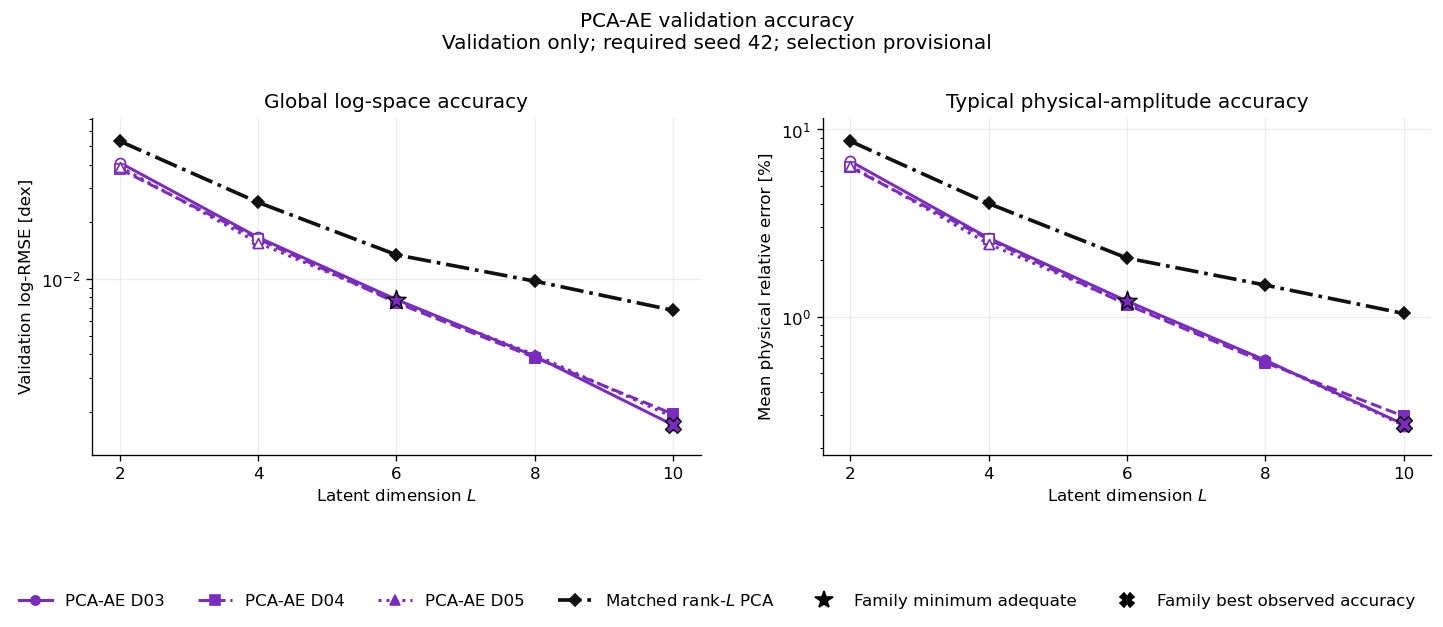

In [11]:
def shared_metric_limits(
    metric_name,
):
    """
    Return common log limits from every authenticated neural and PCA row.
    
    Arguments:
        metric_name (str):
            Validation metric key with a shared presentation contract.
    
    Returns:
        limits (tuple[float, float]):
            Positive display-unit limits shared by the method notebooks.
    """
    presentation = METRIC_PRESENTATION[metric_name]
    scale = float(presentation["scale"])
    values = [
        scale * float(row[metric_name])
        for row in RESULT_TABLE_ROWS
    ]
    values.extend(
        scale * float(row[metric_name])
        for row in PCA_REFERENCE_ROWS
    )
    return positive_log_limits(values)


VALIDATION_SUBTITLE = (
    "Validation only; required seed "
    + ", ".join(
        str(seed) for seed in policy["replicates"]["required_seeds"]
    )
    + "; selection provisional"
)


def plot_pca_ae_validation_metric(
    axis,
    metric_name,
):
    """
    Plot one PCA-AE metric using the shared visual contract.
    
    Arguments:
        axis (matplotlib.axes.Axes):
            Destination axes.
        metric_name (str):
            Validation metric key in the shared presentation mapping.
    """
    presentation = METRIC_PRESENTATION[metric_name]
    plot_validation_metric_panel(
        axis,
        PCA_AE_PLOT_ROWS,
        PCA_REFERENCE_ROWS,
        LATENT_DIMENSIONS,
        metric_name,
        minimum_adequate_cell_ids={minimum_adequate_cell_id},
        best_accuracy_cell_ids={best_accuracy_cell_id},
        scale=float(presentation["scale"]),
        ylabel=str(presentation["ylabel"]),
        y_limits=shared_metric_limits(metric_name),
    )
    axis.set_title(str(presentation["title"]))


def finish_summary_figure(
    figure,
    axes,
    title,
    filename,
):
    """
    Add the common legend, status subtitle, and margins to a summary figure.
    
    Arguments:
        figure (matplotlib.figure.Figure):
            Two-panel validation figure.
        axes (numpy.ndarray):
            Axes whose series share one legend.
        title (str):
            Figure-level scientific title.
        filename (str):
            Destination PDF filename.
    """
    handles, labels = axes[-1].get_legend_handles_labels()
    role_handles = selection_legend_handles()
    figure.legend(
        [*handles, *role_handles],
        [*labels, *(handle.get_label() for handle in role_handles)],
        loc="lower center",
        bbox_to_anchor=(0.5, 0.01),
        ncol=6,
        frameon=False,
    )
    figure.suptitle(f"{title}\n{VALIDATION_SUBTITLE}", y=0.99)
    figure.subplots_adjust(
        left=0.08,
        right=0.98,
        bottom=0.28,
        top=0.82,
        wspace=0.20,
    )
    save_figure(figure, filename)


figure, axes = plt.subplots(1, 2, figsize=FIGURE_SIZES["summary"])
plot_pca_ae_validation_metric(axes[0], "log10_rmse")
plot_pca_ae_validation_metric(axes[1], "mean_relative_error")
finish_summary_figure(
    figure,
    axes,
    "PCA-AE validation accuracy",
    "PCA_AE_Validation_Accuracy.pdf",
)


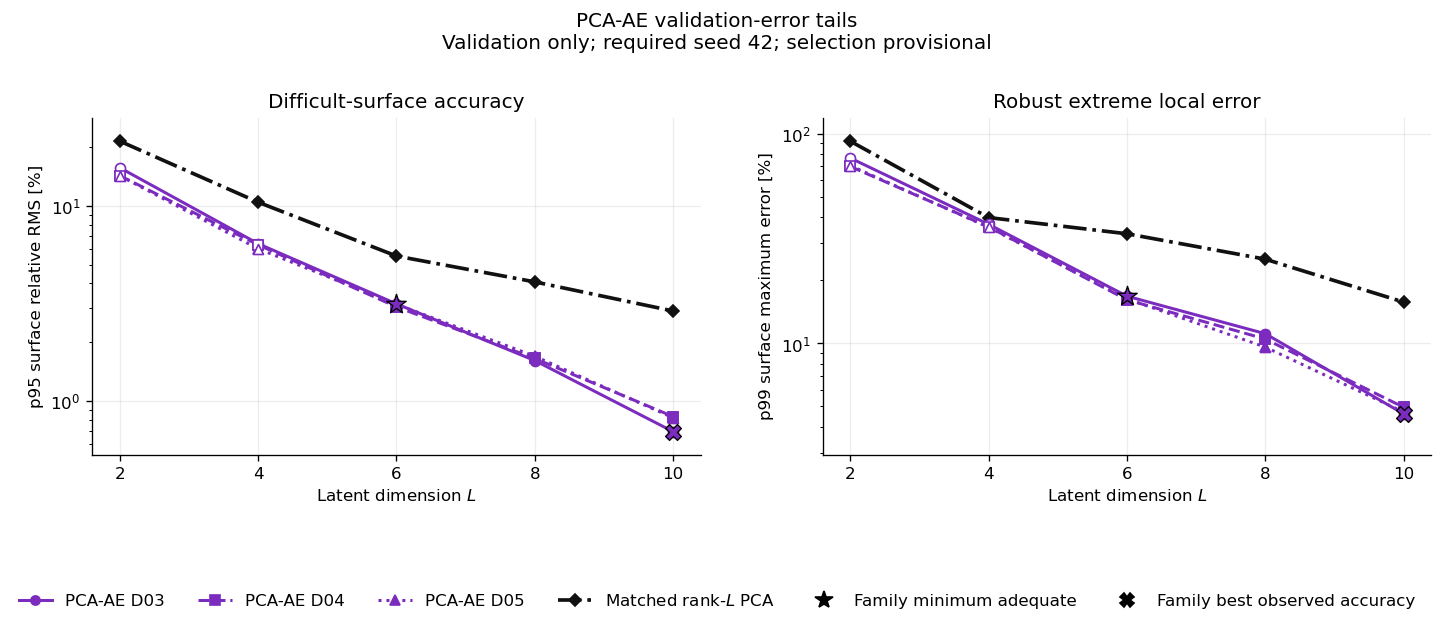

In [12]:
figure, axes = plt.subplots(1, 2, figsize=FIGURE_SIZES["summary"])
plot_pca_ae_validation_metric(axes[0], "surface_relative_rmse_p95")
plot_pca_ae_validation_metric(axes[1], "surface_relative_maximum_p99")
finish_summary_figure(
    figure,
    axes,
    "PCA-AE validation-error tails",
    "PCA_AE_Validation_Tails.pdf",
)


## 6. Learned coefficient error and the fixed rank-30 floor

Orthonormal projection makes the aggregate squared error additive:

$$
E_{\rm total}=E_{\rm coefficient}+E_{\rm PCA,30}.
$$

The history fields `coefficient_normalized_mse`, `pca_floor_normalized_mse`, and `normalized_mse` store these terms exactly at each epoch. The rank-30 floor is different from the matched rank-$L$ PCA baseline used above.


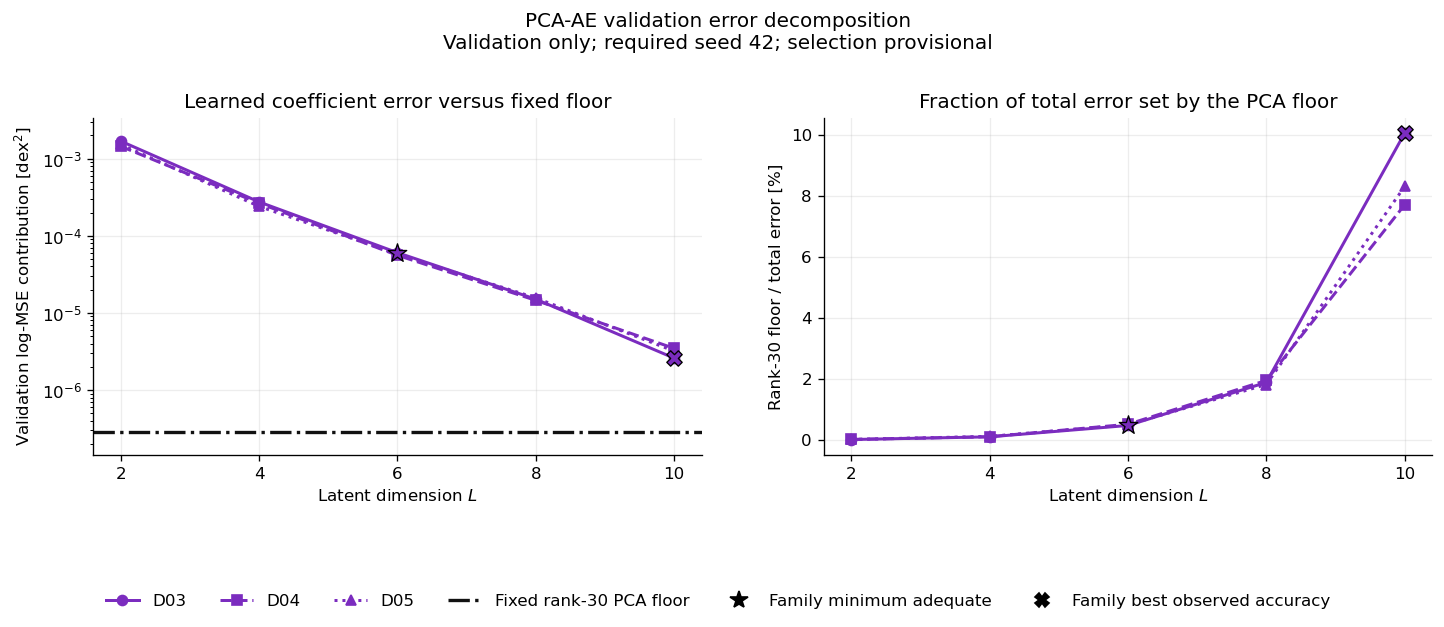

PosixPath('/Users/s2227120/IAFlowCloud/Figure/NLA/PCA_AE/PCA_AE_Error_Decomposition.pdf')

In [13]:
normalization_scale = float(pca_metrics["normalization_scale"])
floor_values = []
DECOMPOSITION = {}

for key in sorted(RUN_DATA):
    data = RUN_DATA[key]
    validation = data["best_history_record"]["validation"]
    coefficient_normalized_mse = float(validation["coefficient_normalized_mse"])
    floor_normalized_mse = float(validation["pca_floor_normalized_mse"])
    total_normalized_mse = float(validation["normalized_mse"])
    if not np.isclose(
        coefficient_normalized_mse + floor_normalized_mse,
        total_normalized_mse,
        rtol=1.0e-12,
        atol=1.0e-15,
    ):
        raise ValueError(f"Invalid PCA-floor decomposition for {key}.")
    if not np.isclose(
        total_normalized_mse,
        data["metrics"]["normalized_mse"],
        rtol=1.0e-5,
        atol=2.0e-10,
    ):
        raise ValueError(f"History/full-validation mismatch for {key}.")
    coefficient_log10_mse = coefficient_normalized_mse * normalization_scale**2
    floor_log10_mse = floor_normalized_mse * normalization_scale**2
    total_log10_mse = total_normalized_mse * normalization_scale**2
    floor_values.append(floor_log10_mse)
    DECOMPOSITION[key] = {
        "coefficient_log10_mse": coefficient_log10_mse,
        "floor_log10_mse": floor_log10_mse,
        "total_log10_mse": total_log10_mse,
        "floor_fraction": floor_log10_mse / total_log10_mse,
    }

if not floor_values:
    raise RuntimeError("No PCA-AE decomposition records are available.")
if not np.allclose(floor_values, floor_values[0], rtol=1.0e-12, atol=0.0):
    raise ValueError("The supposedly fixed rank-30 floor changes between runs.")
if not np.isclose(
    floor_values[0],
    rank_30_metrics["log10_mse"],
    rtol=1.0e-6,
    atol=1.0e-15,
):
    raise ValueError("History PCA floor does not match rank-30 PCA validation.")

figure, axes = plt.subplots(
    1,
    2,
    figsize=FIGURE_SIZES["summary"],
)
coefficient_display_values = [floor_values[0]]
for depth in DEPTHS:
    coefficient_values = np.asarray(
        [
            DECOMPOSITION[(depth, latent_dim)]["coefficient_log10_mse"]
            if (depth, latent_dim) in DECOMPOSITION
            else np.nan
            for latent_dim in LATENT_DIMENSIONS
        ]
    )
    floor_fractions = np.asarray(
        [
            100.0 * DECOMPOSITION[(depth, latent_dim)]["floor_fraction"]
            if (depth, latent_dim) in DECOMPOSITION
            else np.nan
            for latent_dim in LATENT_DIMENSIONS
        ]
    )
    if not np.any(np.isfinite(coefficient_values)):
        continue
    coefficient_display_values.extend(
        coefficient_values[np.isfinite(coefficient_values)]
    )
    label = depth.replace("Depth", "D")
    axes[0].plot(
        LATENT_DIMENSIONS,
        coefficient_values,
        color=FAMILY_COLORS["PCA_AE"],
        linestyle=DEPTH_LINESTYLES[depth],
        marker=DEPTH_MARKERS[depth],
        linewidth=1.8,
        label=label,
    )
    axes[1].plot(
        LATENT_DIMENSIONS,
        floor_fractions,
        color=FAMILY_COLORS["PCA_AE"],
        linestyle=DEPTH_LINESTYLES[depth],
        marker=DEPTH_MARKERS[depth],
        linewidth=1.8,
        label=label,
    )

axes[0].axhline(
    floor_values[0],
    color=FAMILY_COLORS["PCA"],
    linestyle="-.",
    linewidth=2.0,
    label="Fixed rank-30 PCA floor",
)
for role, key in (
    ("minimum_adequate", minimum_adequate_key),
    ("best_observed_accuracy", best_accuracy_key),
):
    decomposition = DECOMPOSITION[key]
    for axis, value in (
        (axes[0], decomposition["coefficient_log10_mse"]),
        (axes[1], 100.0 * decomposition["floor_fraction"]),
    ):
        axis.scatter(
            [key[1]],
            [value],
            marker=SELECTION_MARKERS[role],
            s=135 if role == "minimum_adequate" else 85,
            facecolor=FAMILY_COLORS["PCA_AE"],
            edgecolor="black",
            linewidth=0.8,
            zorder=7,
        )

axes[0].set(
    xlabel="Latent dimension $L$",
    ylabel="Validation log-MSE contribution [dex$^2$]",
    title="Learned coefficient error versus fixed floor",
    xticks=LATENT_DIMENSIONS,
    yscale="log",
)
axes[0].set_ylim(*positive_log_limits(coefficient_display_values))
axes[1].set(
    xlabel="Latent dimension $L$",
    ylabel="Rank-30 floor / total error [%]",
    title="Fraction of total error set by the PCA floor",
    xticks=LATENT_DIMENSIONS,
)
handles, labels = axes[0].get_legend_handles_labels()
role_handles = selection_legend_handles()
figure.legend(
    [*handles, *role_handles],
    [*labels, *(handle.get_label() for handle in role_handles)],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=6,
)
figure.suptitle(
    "PCA-AE validation error decomposition\n"
    + VALIDATION_SUBTITLE,
    y=0.99,
)
figure.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.28,
    top=0.82,
    wspace=0.20,
)
save_figure(figure, "PCA_AE_Error_Decomposition.pdf")


## 7. Convergence, early stopping, and epoch ceilings

The complete convergence table retains optimization and stopping evidence for every currently available PCA-AE representative. The accompanying 2×2 figure is restricted to the authenticated minimum-adequate diagnostic representative, matching the direct-AE notebook and avoiding an unreadable all-grid history plot. Wall-clock duration is deliberately excluded from model ranking because some trajectories resumed and detached MPS work may have overlapped.


In [14]:
CONVERGENCE = {}
convergence_rows = []

for key in sorted(RUN_DATA):
    depth, latent_dim = key
    data = RUN_DATA[key]
    summary = data["summary"]
    history = data["history"]
    configured_epochs = int(data["config"].training.epochs)
    first_target_epoch = next(
        (
            int(row["epoch"])
            for row in history
            if row["validation"]["variance_recovered"]
            >= TARGET_VARIANCE_RECOVERED
        ),
        None,
    )
    learning_rates = np.asarray(
        [float(row["learning_rate"]) for row in history]
    )
    reductions = int(np.sum(learning_rates[1:] < learning_rates[:-1]))
    resume_path = data["run_directory"] / "ResumeHistory.json"
    if resume_path.is_file():
        with resume_path.open("r", encoding="utf-8") as stream:
            resume_events = json.load(stream)
        if not isinstance(resume_events, list):
            raise ValueError(f"Invalid resume history: {resume_path}")
    else:
        resume_events = []
    cap_limited = bool(
        not summary["stopped_early"]
        and int(history[-1]["epoch"]) >= configured_epochs
    )
    status = "epoch ceiling" if cap_limited else "early stopped"
    CONVERGENCE[key] = {
        "first_target_epoch": first_target_epoch,
        "learning_rate_reductions": reductions,
        "resume_events": len(resume_events),
        "cap_limited": cap_limited,
        "status": status,
    }
    convergence_rows.append(
        (
            depth,
            latent_dim,
            summary["best_epoch"],
            summary["epochs_completed"],
            summary["epochs_completed"] - summary["best_epoch"],
            first_target_epoch if first_target_epoch is not None else "NA",
            f'{learning_rates[-1]:.2e}',
            reductions,
            len(resume_events),
            status,
        )
    )

display_markdown_table(
    (
        "Depth",
        "Latent",
        "Best epoch",
        "Epochs",
        "After best",
        "First epoch ≥0.999",
        "Final LR",
        "LR drops",
        "Resumes",
        "Stopping status",
    ),
    convergence_rows,
)


| Depth | Latent | Best epoch | Epochs | After best | First epoch ≥0.999 | Final LR | LR drops | Resumes | Stopping status |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Depth03 | 2 | 313 | 363 | 50 | NA | 1.25e-05 | 4 | 0 | early stopped |
| Depth03 | 4 | 560 | 610 | 50 | NA | 1.00e-07 | 11 | 0 | early stopped |
| Depth03 | 6 | 962 | 1012 | 50 | 242 | 1.00e-07 | 11 | 2 | early stopped |
| Depth03 | 8 | 919 | 969 | 50 | 86 | 1.00e-07 | 11 | 0 | early stopped |
| Depth03 | 10 | 1493 | 1500 | 7 | 73 | 3.13e-06 | 6 | 4 | epoch ceiling |
| Depth04 | 2 | 322 | 372 | 50 | NA | 3.91e-07 | 9 | 0 | early stopped |
| Depth04 | 4 | 474 | 524 | 50 | NA | 1.95e-07 | 10 | 0 | early stopped |
| Depth04 | 6 | 766 | 816 | 50 | 114 | 1.00e-07 | 11 | 0 | early stopped |
| Depth04 | 8 | 737 | 787 | 50 | 47 | 1.95e-07 | 10 | 0 | early stopped |
| Depth04 | 10 | 965 | 1015 | 50 | 45 | 1.95e-07 | 10 | 0 | early stopped |
| Depth05 | 2 | 110 | 160 | 50 | NA | 3.13e-06 | 6 | 0 | early stopped |
| Depth05 | 4 | 271 | 321 | 50 | NA | 3.13e-06 | 6 | 0 | early stopped |
| Depth05 | 6 | 364 | 414 | 50 | 88 | 1.95e-07 | 10 | 0 | early stopped |
| Depth05 | 8 | 686 | 736 | 50 | 36 | 1.00e-07 | 11 | 0 | early stopped |
| Depth05 | 10 | 886 | 936 | 50 | 36 | 3.91e-07 | 9 | 0 | early stopped |

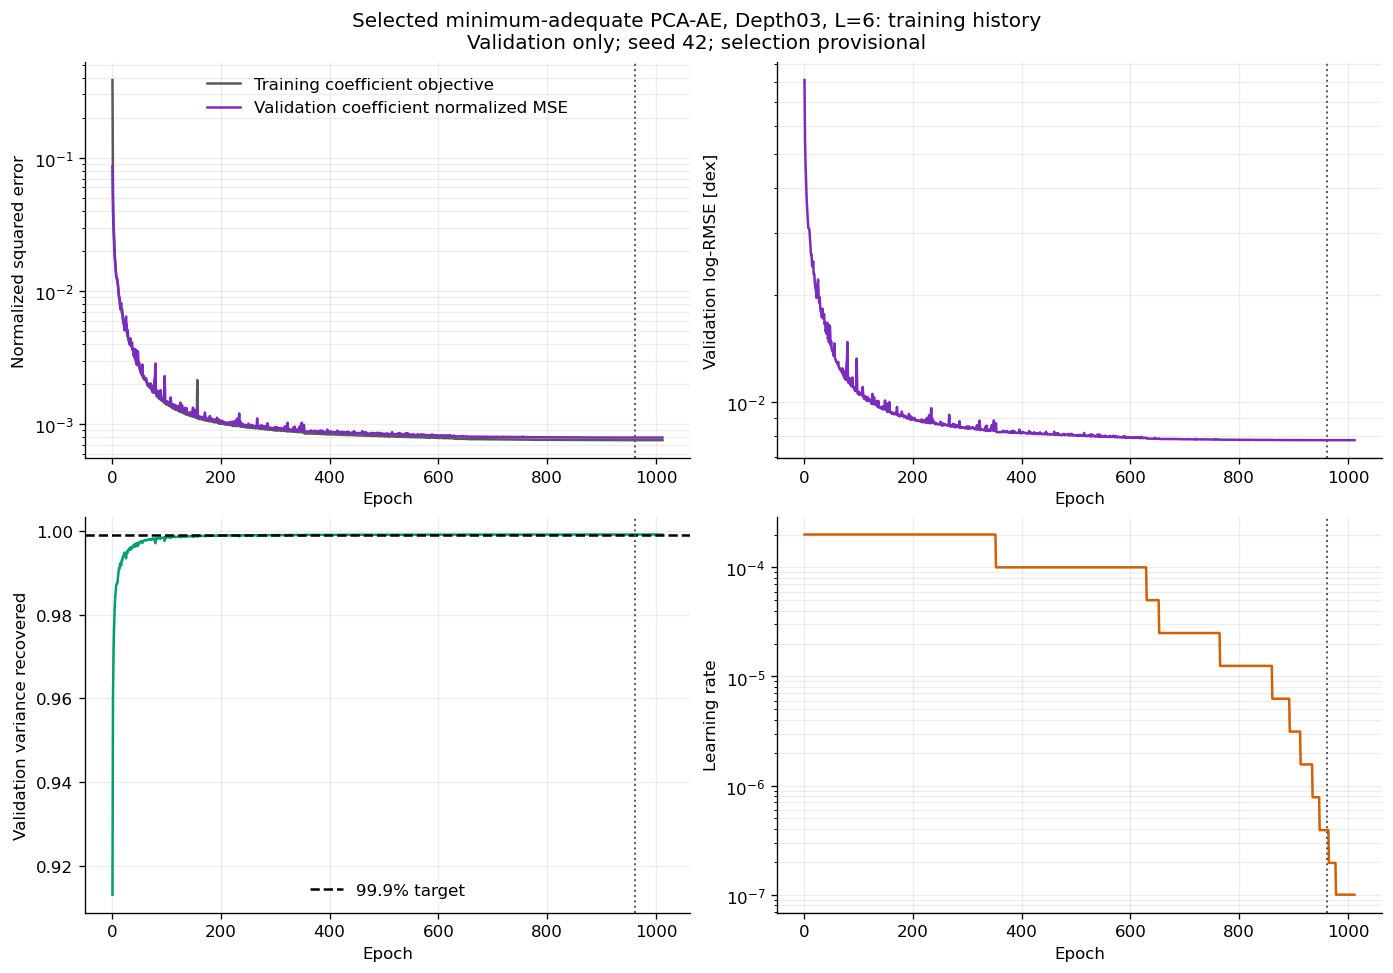

Best epoch 962 of 1012; stopped early: True.


In [15]:
selected_training_data = RUN_DATA[selected_diagnostic_key]
selected_history = selected_training_data["history"]
selected_summary = selected_training_data["summary"]
selected_family_color = FAMILY_COLORS["PCA_AE"]

epochs = np.asarray([int(row["epoch"]) for row in selected_history])
train_coefficient_loss = np.asarray(
    [float(row["train_loss"]) for row in selected_history]
)
validation_coefficient_loss = np.asarray(
    [
        float(row["validation"]["coefficient_normalized_mse"])
        for row in selected_history
    ]
)
validation_log_rmse = np.asarray(
    [float(row["validation"]["log10_rmse"]) for row in selected_history]
)
validation_variance = np.asarray(
    [
        float(row["validation"]["variance_recovered"])
        for row in selected_history
    ]
)
learning_rate = np.asarray(
    [float(row["learning_rate"]) for row in selected_history]
)

figure, axes = plt.subplots(
    2,
    2,
    figsize=FIGURE_SIZES["selected_training"],
    constrained_layout=True,
)
axes[0, 0].semilogy(
    epochs,
    train_coefficient_loss,
    color="0.35",
    label="Training coefficient objective",
)
axes[0, 0].semilogy(
    epochs,
    validation_coefficient_loss,
    color=selected_family_color,
    label="Validation coefficient normalized MSE",
)
axes[0, 0].set(xlabel="Epoch", ylabel="Normalized squared error")
axes[0, 0].legend(frameon=False)
axes[0, 1].semilogy(
    epochs,
    validation_log_rmse,
    color=selected_family_color,
)
axes[0, 1].set(xlabel="Epoch", ylabel="Validation log-RMSE [dex]")
axes[1, 0].plot(epochs, validation_variance, color="#009E73")
axes[1, 0].axhline(
    TARGET_VARIANCE_RECOVERED,
    color="black",
    linestyle="--",
    label="99.9% target",
)
axes[1, 0].set(
    xlabel="Epoch",
    ylabel="Validation variance recovered",
)
axes[1, 0].legend(frameon=False)
axes[1, 1].semilogy(epochs, learning_rate, color="#D55E00")
axes[1, 1].set(xlabel="Epoch", ylabel="Learning rate")
for axis in axes.flat:
    axis.axvline(
        selected_summary["best_epoch"],
        color="0.35",
        linestyle=":",
        linewidth=1.2,
    )
    axis.grid(True, which="both", alpha=0.22)

figure.suptitle(selected_figure_title("training history"))
save_figure(figure, "PCA_AE_Selected_Training_History.pdf")
print(
    f"Best epoch {selected_summary['best_epoch']} of "
    f"{selected_summary['epochs_completed']}; "
    f"stopped early: {selected_summary['stopped_early']}."
)


## 8. Selected full-validation diagnostics and depth sensitivity

The detailed 2x2 figure follows the authenticated family minimum-adequate selection rather than a manually chosen depth or bottleneck. It combines pointwise mean and maximum error maps with complete-validation survival curves. Map normalizations and survival-axis limits are shared with the independently selected AE diagnostic run.

The supporting depth-sensitivity figure compares every available depth at each family's selected architecture and bottleneck. Its normalizations are pooled across the complete AE and PCA-AE depth sets, while unavailable panels remain explicit. All arrays cover the 10,000-surface validation split; no fresh inference is performed.


In [16]:
EXPECTED_DIAGNOSTIC_KEYS = {
    "mean_relative_error_map",
    "maximum_relative_error_map",
    "surface_relative_rmse",
    "surface_relative_maximum",
    "worst_split_positions",
    "worst_source_indices",
    "worst_target_log10",
    "worst_prediction_log10",
}
EXPECTED_DIAGNOSTIC_SHAPES = {
    "mean_relative_error_map": (31, 101),
    "maximum_relative_error_map": (31, 101),
    "surface_relative_rmse": (EXPECTED_VALIDATION_SAMPLES,),
    "surface_relative_maximum": (EXPECTED_VALIDATION_SAMPLES,),
    "worst_split_positions": (12,),
    "worst_source_indices": (12,),
    "worst_target_log10": (12, 31, 101),
    "worst_prediction_log10": (12, 31, 101),
}


def load_complete_validation_diagnostics(
    run_directory,
    expected_metrics=None,
):
    """
    Load and validate one complete-validation diagnostic artifact pair.
    
    Arguments:
        run_directory (pathlib.Path):
            Authenticated compressor run directory.
        expected_metrics (dict or None):
            Validation metrics to cross-check, when available.
    
    Returns:
        diagnostics (dict):
            Stored diagnostic summary and finite arrays.
    """
    run_directory = Path(run_directory)
    summary = read_json(run_directory / "ValidationDiagnostics.json")
    if summary["complete_validation_split"] is not True:
        raise ValueError(f"Incomplete diagnostics: {run_directory}")
    if int(summary["number_of_surfaces"]) != EXPECTED_VALIDATION_SAMPLES:
        raise ValueError(f"Wrong diagnostic sample count: {run_directory}")
    with np.load(
        run_directory / "ValidationDiagnostics.npz",
        allow_pickle=False,
    ) as stored:
        if set(stored.files) != EXPECTED_DIAGNOSTIC_KEYS:
            raise ValueError(f"Unexpected diagnostics: {run_directory}")
        arrays = {name: np.asarray(stored[name]) for name in stored.files}
    for name, expected_shape in EXPECTED_DIAGNOSTIC_SHAPES.items():
        if arrays[name].shape != expected_shape:
            raise ValueError(f"Invalid {name} shape in {run_directory}.")
        if not np.all(np.isfinite(arrays[name])):
            raise ValueError(f"Non-finite {name} values in {run_directory}.")
    if expected_metrics is not None:
        for name in (
            "surface_relative_rmse_p95",
            "surface_relative_rmse_p99",
            "surface_relative_maximum_p95",
            "surface_relative_maximum_p99",
            "maximum_relative_error",
        ):
            if name not in expected_metrics:
                continue
            if not np.isclose(
                summary[name],
                float(expected_metrics[name]),
                rtol=2.0e-6,
                atol=1.0e-8,
            ):
                raise ValueError(
                    f"Diagnostic/metric mismatch in {run_directory}: {name}"
                )
    return {"summary": summary, "arrays": arrays}


def load_result_row_diagnostics(
    result_row,
):
    """
    Load diagnostics for one current eligible representative result row.
    
    Arguments:
        result_row (dict[str, str]):
            Authenticated aggregate row from ValidationResults.csv.
    
    Returns:
        diagnostics (dict):
            Complete-validation diagnostic summary and arrays.
    """
    run_directory = resolve_project_path(
        result_row["representative_run_directory"],
        f"representative run for {result_row['cell_id']}",
    )
    live_matches = [
        audit
        for audit in ALL_AUDITS
        if (
            audit["cell_id"] == result_row["cell_id"]
            and audit.get("run_directory")
            == result_row["representative_run_directory"]
            and audit["eligible_for_comparison"]
            and audit["diagnostics_ready"]
        )
    ]
    if len(live_matches) != 1:
        raise RuntimeError(
            "Representative diagnostics are no longer uniquely eligible: "
            f"{result_row['cell_id']}."
        )
    return load_complete_validation_diagnostics(
        run_directory,
        expected_metrics=result_row,
    )


SELECTED_DIAGNOSTICS = load_complete_validation_diagnostics(
    selected_diagnostic_directory,
    expected_metrics=RUN_DATA[selected_diagnostic_key]["metrics"],
)

depth_sensitivity_latent_dim = selected_diagnostic_key[1]
DEPTH_SENSITIVITY_DIAGNOSTICS = {}
omitted_depth_sensitivity = []
for depth in DEPTHS:
    key = (depth, depth_sensitivity_latent_dim)
    if key not in RUN_DATA:
        omitted_depth_sensitivity.append(f"{depth}: unavailable cell")
        continue
    if not CELL_RESULTS[key]["diagnostics_ready"]:
        omitted_depth_sensitivity.append(f"{depth}: diagnostics unavailable")
        continue
    DEPTH_SENSITIVITY_DIAGNOSTICS[depth] = (
        load_complete_validation_diagnostics(
            RUN_DATA[key]["run_directory"],
            expected_metrics=RUN_DATA[key]["metrics"],
        )
    )
if selected_diagnostic_key[0] not in DEPTH_SENSITIVITY_DIAGNOSTICS:
    raise RuntimeError("Selected PCA-AE depth diagnostics are unavailable.")

counterpart_run = diagnostic_runs["AE"]
require_keys(
    counterpart_run,
    (
        "cell_id",
        "architecture",
        "depth",
        "latent_dim",
        "run_directory",
        "artifact_sha256",
    ),
    "AE diagnostic run",
)
if counterpart_run["cell_id"] != selections["by_family"]["AE"][
    "diagnostic_representative"
]:
    raise RuntimeError("The shared-scale AE diagnostic run is inconsistent.")
counterpart_directory = resolve_project_path(
    counterpart_run["run_directory"],
    "AE diagnostic run directory",
)
for name in ("ValidationDiagnostics.json", "ValidationDiagnostics.npz"):
    require_keys(counterpart_run["artifact_sha256"], (name,), "AE hashes")
    authenticate_file(
        counterpart_directory / name,
        counterpart_run["artifact_sha256"][name],
        f"selected AE {name}",
    )
COUNTERPART_DIAGNOSTICS = load_complete_validation_diagnostics(
    counterpart_directory
)

COUNTERPART_DEPTH_SENSITIVITY_DIAGNOSTICS = {}
for depth in DEPTHS:
    matches = [
        row
        for row in RESULT_TABLE_ROWS
        if (
            row["model_family"] == "Direct_AE"
            and row["architecture"] == counterpart_run["architecture"]
            and row["depth"] == depth
            and int(row["latent_dim"]) == int(counterpart_run["latent_dim"])
        )
    ]
    if len(matches) > 1:
        raise RuntimeError(f"Duplicate AE depth-sensitivity row: {depth}.")
    if matches and parse_csv_boolean(
        matches[0]["diagnostics_ready"],
        "diagnostics_ready",
    ):
        COUNTERPART_DEPTH_SENSITIVITY_DIAGNOSTICS[depth] = (
            load_result_row_diagnostics(matches[0])
        )

source_path = reference_template.resolve_path(reference_template.data.source_path)
with h5py.File(source_path, "r") as source_file:
    redshifts = source_file["coordinates/z"][:]
    wavenumbers = source_file["coordinates/k"][:]

assert redshifts.shape == (31,)
assert wavenumbers.shape == (101,)
print(
    "Selected PCA-AE diagnostics:",
    diagnostic_cell_id,
    selected_diagnostic_directory.relative_to(PROJECT_ROOT),
)
if omitted_depth_sensitivity:
    print("Omitted depth-sensitivity peers:")
    for reason in omitted_depth_sensitivity:
        print(" ", reason)


Selected PCA-AE diagnostics: PCA_AE:PCA_AE:Depth03:L06 Runs/NLA/PCA_AE/Depth03/Latent06/20260822-192700


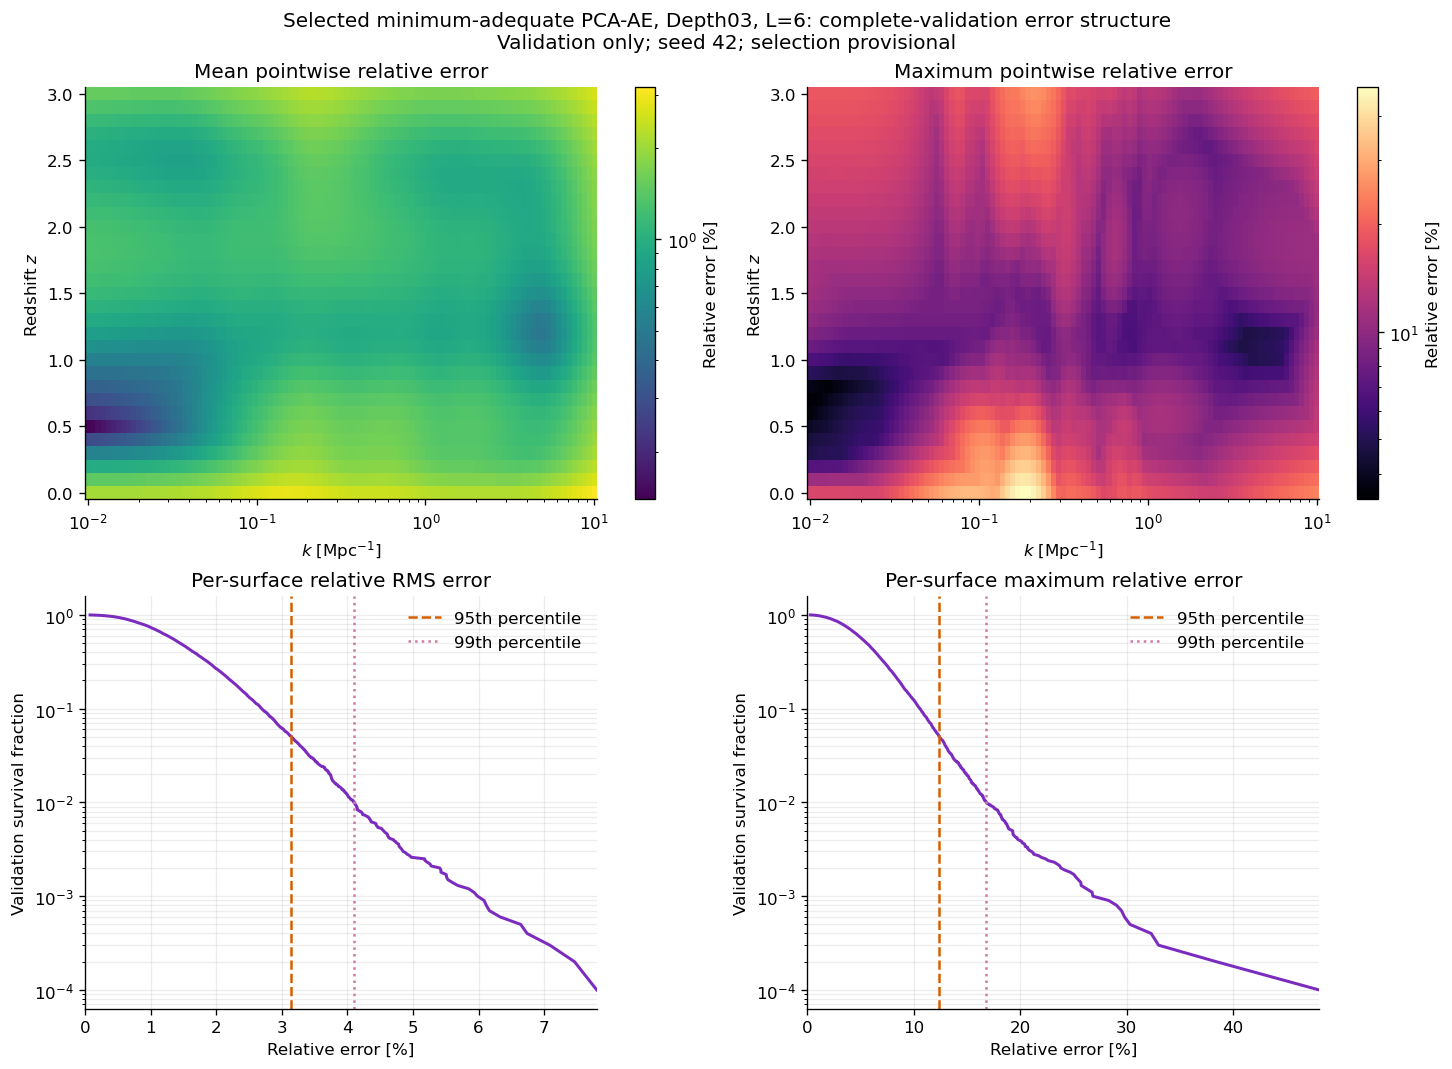

PosixPath('/Users/s2227120/IAFlowCloud/Figure/NLA/PCA_AE/PCA_AE_Selected_Validation_Diagnostics.pdf')

In [17]:
selected_arrays = SELECTED_DIAGNOSTICS["arrays"]
counterpart_arrays = COUNTERPART_DIAGNOSTICS["arrays"]
selected_metrics = RUN_DATA[selected_diagnostic_key]["metrics"]
mean_percent = 100.0 * selected_arrays["mean_relative_error_map"]
maximum_percent = 100.0 * selected_arrays["maximum_relative_error_map"]
counterpart_mean_percent = (
    100.0 * counterpart_arrays["mean_relative_error_map"]
)
counterpart_maximum_percent = (
    100.0 * counterpart_arrays["maximum_relative_error_map"]
)
mean_norm = shared_positive_log_norm(
    (mean_percent, counterpart_mean_percent)
)
maximum_norm = shared_positive_log_norm(
    (maximum_percent, counterpart_maximum_percent)
)

figure, axes = plt.subplots(
    2,
    2,
    figsize=FIGURE_SIZES["selected_diagnostics"],
    constrained_layout=True,
)
mean_image = axes[0, 0].pcolormesh(
    wavenumbers,
    redshifts,
    mean_percent,
    shading="auto",
    cmap="viridis",
    norm=mean_norm,
    linewidth=0.0,
    antialiased=False,
    rasterized=True,
)
maximum_image = axes[0, 1].pcolormesh(
    wavenumbers,
    redshifts,
    maximum_percent,
    shading="auto",
    cmap="magma",
    norm=maximum_norm,
    linewidth=0.0,
    antialiased=False,
    rasterized=True,
)
for axis in axes[0]:
    axis.set(
        xscale="log",
        xlabel=r"$k$ [Mpc$^{-1}$]",
        ylabel=r"Redshift $z$",
    )
    axis.grid(False)
axes[0, 0].set_title("Mean pointwise relative error")
axes[0, 1].set_title("Maximum pointwise relative error")
figure.colorbar(mean_image, ax=axes[0, 0], label="Relative error [%]")
figure.colorbar(maximum_image, ax=axes[0, 1], label="Relative error [%]")

for axis, array_name, p95_name, p99_name, title in (
    (
        axes[1, 0],
        "surface_relative_rmse",
        "surface_relative_rmse_p95",
        "surface_relative_rmse_p99",
        "Per-surface relative RMS error",
    ),
    (
        axes[1, 1],
        "surface_relative_maximum",
        "surface_relative_maximum_p95",
        "surface_relative_maximum_p99",
        "Per-surface maximum relative error",
    ),
):
    ordered, survival = empirical_survival(selected_arrays[array_name])
    shared_upper = 100.0 * max(
        float(np.max(selected_arrays[array_name])),
        float(np.max(counterpart_arrays[array_name])),
    )
    axis.plot(
        100.0 * ordered,
        survival,
        color=selected_family_color,
        linewidth=1.8,
    )
    axis.axvline(
        100.0 * selected_metrics[p95_name],
        color="#D55E00",
        linestyle="--",
        label="95th percentile",
    )
    axis.axvline(
        100.0 * selected_metrics[p99_name],
        color="#CC79A7",
        linestyle=":",
        label="99th percentile",
    )
    axis.set(
        xlim=(0.0, shared_upper),
        yscale="log",
        xlabel="Relative error [%]",
        ylabel="Validation survival fraction",
        title=title,
    )
    axis.grid(True, which="both", alpha=0.22)
    axis.legend(frameon=False)

figure.suptitle(selected_figure_title("complete-validation error structure"))
save_figure(figure, "PCA_AE_Selected_Validation_Diagnostics.pdf")


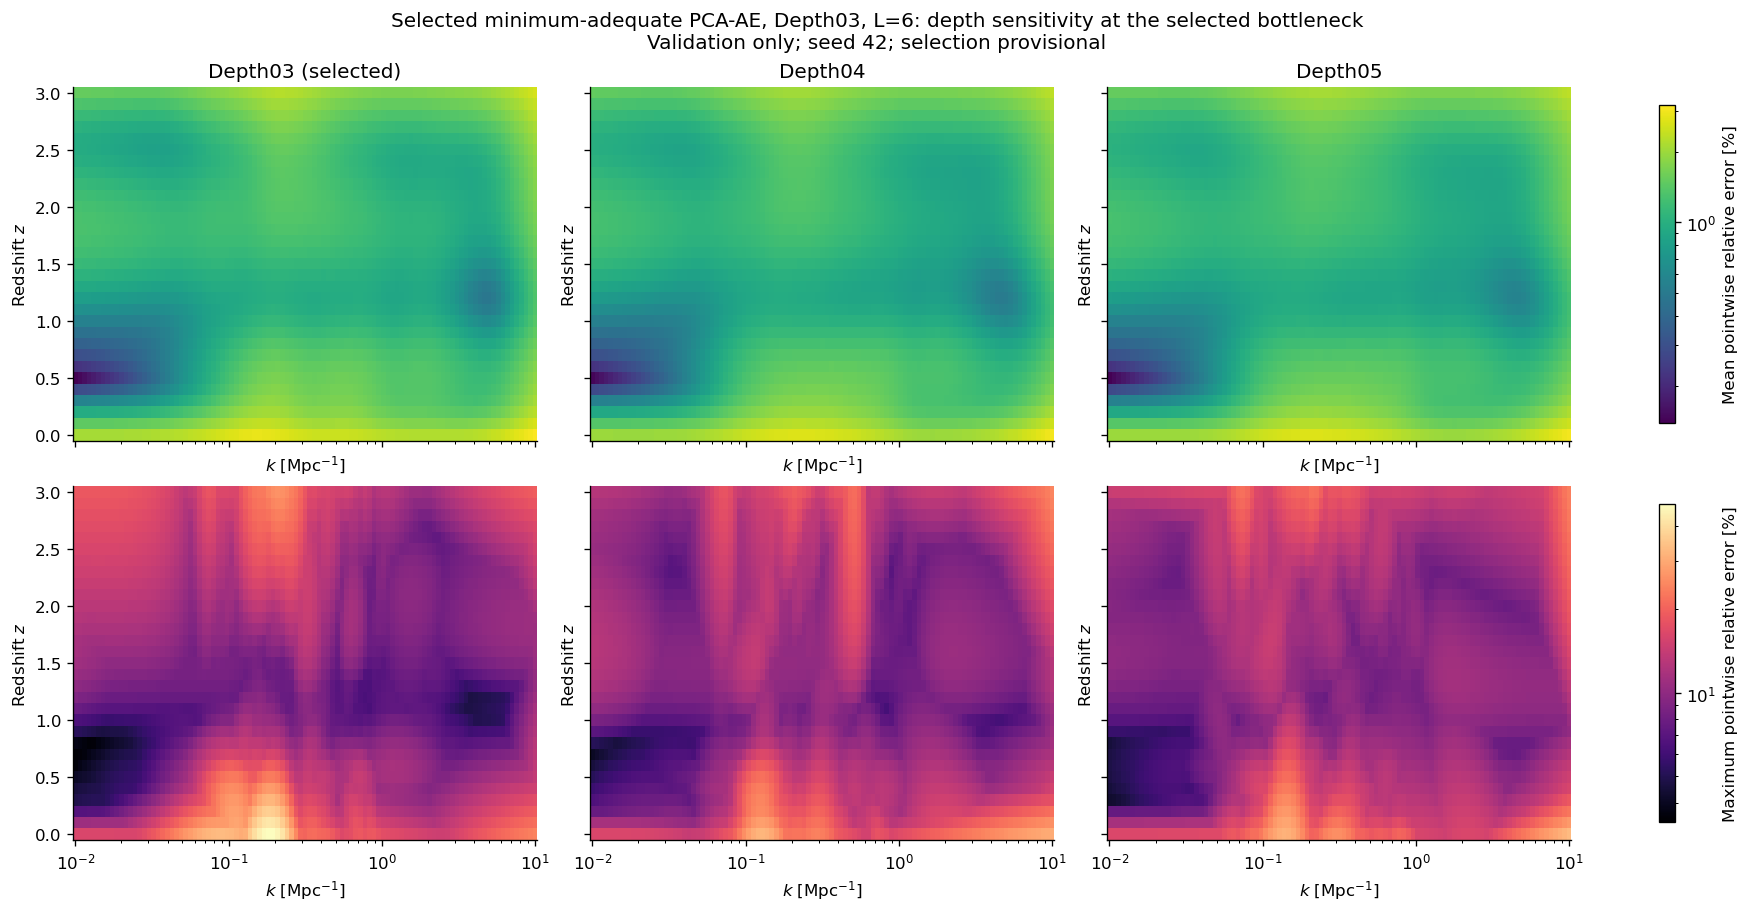

PosixPath('/Users/s2227120/IAFlowCloud/Figure/NLA/PCA_AE/PCA_AE_Selected_Depth_Sensitivity.pdf')

In [18]:
depth_mean_arrays = [
    100.0 * diagnostics["arrays"]["mean_relative_error_map"]
    for diagnostics in (
        *DEPTH_SENSITIVITY_DIAGNOSTICS.values(),
        *COUNTERPART_DEPTH_SENSITIVITY_DIAGNOSTICS.values(),
    )
]
depth_maximum_arrays = [
    100.0 * diagnostics["arrays"]["maximum_relative_error_map"]
    for diagnostics in (
        *DEPTH_SENSITIVITY_DIAGNOSTICS.values(),
        *COUNTERPART_DEPTH_SENSITIVITY_DIAGNOSTICS.values(),
    )
]
depth_mean_norm = shared_positive_log_norm(depth_mean_arrays)
depth_maximum_norm = shared_positive_log_norm(depth_maximum_arrays)

figure, axes = plt.subplots(
    2,
    len(DEPTHS),
    figsize=FIGURE_SIZES["depth_sensitivity"],
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
mean_image = None
maximum_image = None
for column, depth in enumerate(DEPTHS):
    if depth not in DEPTH_SENSITIVITY_DIAGNOSTICS:
        for row in range(2):
            axes[row, column].set_axis_off()
            axes[row, column].text(
                0.5,
                0.5,
                f"{depth}\nunavailable",
                ha="center",
                va="center",
                transform=axes[row, column].transAxes,
            )
        continue
    arrays = DEPTH_SENSITIVITY_DIAGNOSTICS[depth]["arrays"]
    mean_image = axes[0, column].pcolormesh(
        wavenumbers,
        redshifts,
        100.0 * arrays["mean_relative_error_map"],
        shading="auto",
        cmap="viridis",
        norm=depth_mean_norm,
        linewidth=0.0,
        antialiased=False,
        rasterized=True,
    )
    maximum_image = axes[1, column].pcolormesh(
        wavenumbers,
        redshifts,
        100.0 * arrays["maximum_relative_error_map"],
        shading="auto",
        cmap="magma",
        norm=depth_maximum_norm,
        linewidth=0.0,
        antialiased=False,
        rasterized=True,
    )
    depth_title = depth
    if depth == selected_diagnostic_key[0]:
        depth_title += " (selected)"
    axes[0, column].set_title(depth_title)
    for row in range(2):
        axes[row, column].set_xscale("log")
        axes[row, column].set_xlabel(r"$k$ [Mpc$^{-1}$]")
        axes[row, column].grid(False)
    axes[0, column].set_ylabel(r"Redshift $z$")
    axes[1, column].set_ylabel(r"Redshift $z$")

if mean_image is None or maximum_image is None:
    raise RuntimeError("No PCA-AE depth-sensitivity maps are available.")
figure.colorbar(
    mean_image,
    ax=axes[0, :],
    label="Mean pointwise relative error [%]",
    shrink=0.9,
)
figure.colorbar(
    maximum_image,
    ax=axes[1, :],
    label="Maximum pointwise relative error [%]",
    shrink=0.9,
)
figure.suptitle(
    selected_figure_title("depth sensitivity at the selected bottleneck")
)
save_figure(figure, "PCA_AE_Selected_Depth_Sensitivity.pdf")


## 9. Worst stored validation reconstructions

The following are the three validation surfaces with the largest stored per-surface maximum physical relative errors for the authenticated diagnostic representative. They are independently ranked within this model and are not matched to the AE rows. Both family PDFs use colour limits pooled across their two selected worst-case sets.


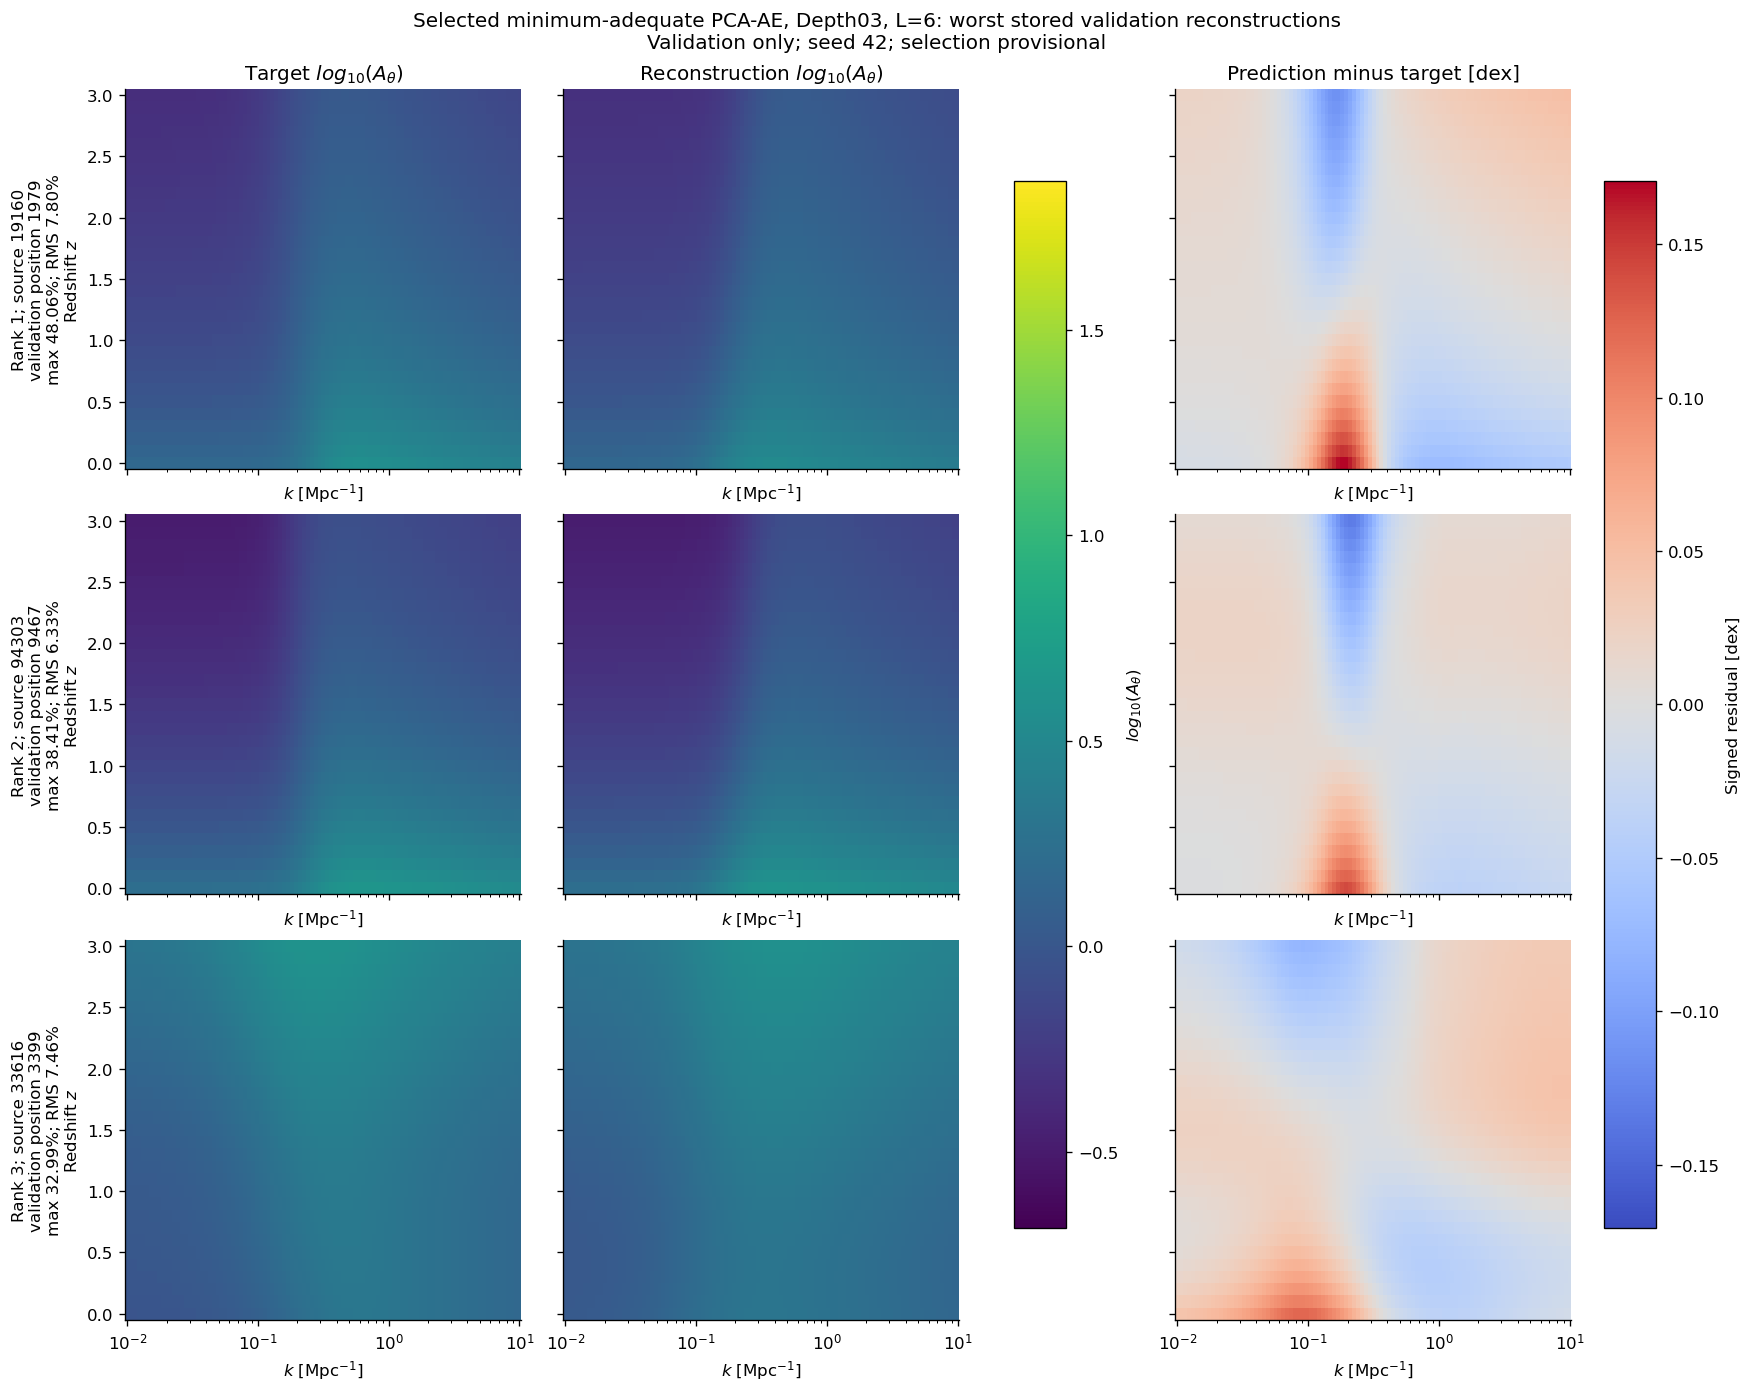

PosixPath('/Users/s2227120/IAFlowCloud/Figure/NLA/PCA_AE/PCA_AE_Selected_Worst_Reconstructions.pdf')

In [19]:
candidate_positions = np.asarray(
    selected_arrays["worst_split_positions"],
    dtype=int,
)
candidate_errors = selected_arrays["surface_relative_maximum"][
    candidate_positions
]
selected_worst = np.argsort(candidate_errors)[::-1][:3]

worst_targets = selected_arrays["worst_target_log10"][selected_worst]
worst_predictions = selected_arrays["worst_prediction_log10"][selected_worst]
worst_source_indices = selected_arrays["worst_source_indices"][selected_worst]
worst_positions = candidate_positions[selected_worst]
surface_rms = selected_arrays["surface_relative_rmse"]
surface_maximum = selected_arrays["surface_relative_maximum"]
worst_errors = surface_maximum[worst_positions]
worst_rms_errors = surface_rms[worst_positions]
worst_residuals = worst_predictions - worst_targets

counterpart_positions = np.asarray(
    counterpart_arrays["worst_split_positions"],
    dtype=int,
)
counterpart_errors = counterpart_arrays["surface_relative_maximum"][
    counterpart_positions
]
counterpart_order = np.argsort(counterpart_errors)[::-1][:3]
counterpart_targets = counterpart_arrays["worst_target_log10"][
    counterpart_order
]
counterpart_predictions = counterpart_arrays["worst_prediction_log10"][
    counterpart_order
]
counterpart_residuals = counterpart_predictions - counterpart_targets

amplitude_minimum = float(
    min(
        np.min(worst_targets),
        np.min(worst_predictions),
        np.min(counterpart_targets),
        np.min(counterpart_predictions),
    )
)
amplitude_maximum = float(
    max(
        np.max(worst_targets),
        np.max(worst_predictions),
        np.max(counterpart_targets),
        np.max(counterpart_predictions),
    )
)
residual_limit = max(
    float(np.max(np.abs(worst_residuals))),
    float(np.max(np.abs(counterpart_residuals))),
    np.finfo(np.float32).eps,
)

figure, axes = plt.subplots(
    3,
    3,
    figsize=FIGURE_SIZES["worst_reconstructions"],
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
for row in range(3):
    target_image = axes[row, 0].pcolormesh(
        wavenumbers,
        redshifts,
        worst_targets[row],
        shading="auto",
        cmap="viridis",
        vmin=amplitude_minimum,
        vmax=amplitude_maximum,
        linewidth=0.0,
        antialiased=False,
        rasterized=True,
    )
    axes[row, 1].pcolormesh(
        wavenumbers,
        redshifts,
        worst_predictions[row],
        shading="auto",
        cmap="viridis",
        vmin=amplitude_minimum,
        vmax=amplitude_maximum,
        linewidth=0.0,
        antialiased=False,
        rasterized=True,
    )
    residual_image = axes[row, 2].pcolormesh(
        wavenumbers,
        redshifts,
        worst_residuals[row],
        shading="auto",
        cmap="coolwarm",
        vmin=-residual_limit,
        vmax=residual_limit,
        linewidth=0.0,
        antialiased=False,
        rasterized=True,
    )
    axes[row, 0].set_ylabel(
        f"Rank {row + 1}; source {worst_source_indices[row]}\n"
        f"validation position {worst_positions[row]}\n"
        f"max {100.0 * worst_errors[row]:.2f}%; "
        f"RMS {100.0 * worst_rms_errors[row]:.2f}%\n"
        r"Redshift $z$"
    )
    for column in range(3):
        axes[row, column].set_xscale("log")
        axes[row, column].set_xlabel(r"$k$ [Mpc$^{-1}$]")
        axes[row, column].grid(False)

axes[0, 0].set_title(r"Target $log_{10}(A_\theta)$")
axes[0, 1].set_title(r"Reconstruction $log_{10}(A_\theta)$")
axes[0, 2].set_title("Prediction minus target [dex]")
figure.colorbar(
    target_image,
    ax=axes[:, :2],
    label=r"$log_{10}(A_\theta)$",
    shrink=0.85,
)
figure.colorbar(
    residual_image,
    ax=axes[:, 2],
    label="Signed residual [dex]",
    shrink=0.85,
)
figure.suptitle(
    selected_figure_title("worst stored validation reconstructions")
)
save_figure(figure, "PCA_AE_Selected_Worst_Reconstructions.pdf")


## 10. Exploratory validation latent geometry

Latent coordinates are not identifiable across seeds, permutations, rotations, or nonlinear reparameterizations and are not used for model selection. The selected 2×2 diagnostic standardizes coordinates with the complete **training latent export**, then evaluates all 10,000 validation latents. It shows error-coloured validation geometry, training-to-validation marginal stability, and latent-coordinate correlations. The parameter heat map uses pairwise-safe correlations, masks undefined values, and annotates only substantial associations. No training surfaces, test samples, or test latents are read.


In [20]:
latent_data = RUN_DATA[selected_diagnostic_key]
latent_path = latent_data["run_directory"] / "Latents.hdf5"

with h5py.File(latent_path, "r") as latent_file:
    attributes = dict(latent_file.attrs)
    exported_splits = json.loads(attributes["exported_splits"])
    if attributes["model_family"] != "PCA_AE":
        raise ValueError("The selected latent file is not PCA-AE.")
    if int(attributes["pca_rank"]) != EXPECTED_PCA_RANK:
        raise ValueError("The selected latent file has the wrong PCA rank.")
    if int(attributes["latent_dim"]) != selected_diagnostic_key[1]:
        raise ValueError("The selected latent file has the wrong dimension.")
    if attributes["pca_transform_sha256"] != transform.artifact_sha256:
        raise ValueError("The selected latent file uses a different PCA basis.")
    if int(attributes["checkpoint_epoch"]) != latent_data["summary"]["best_epoch"]:
        raise ValueError("The selected latent export uses the wrong checkpoint.")
    if int(attributes["maximum_samples_per_split"]) != -1:
        raise ValueError("The selected latent export is smoke limited.")
    if exported_splits != ["train", "validation"]:
        raise ValueError("Unexpected latent-export split declaration.")
    if "test" in latent_file["splits"]:
        raise RuntimeError("The selected latent export unexpectedly contains test data.")
    
    train_group = latent_file["splits/train"]
    validation_group = latent_file["splits/validation"]
    train_latent = train_group["latent"][:]
    validation_latent = validation_group["latent"][:]
    train_source_indices = train_group["source_indices"][:]
    validation_source_indices = validation_group["source_indices"][:]
    stored_train_mean = np.asarray(train_group.attrs["mean"])
    stored_train_scale = np.asarray(train_group.attrs["standard_deviation"])
    stored_train_covariance = np.asarray(train_group.attrs["covariance"])
    stored_validation_mean = np.asarray(validation_group.attrs["mean"])
    stored_validation_scale = np.asarray(
        validation_group.attrs["standard_deviation"]
    )
    stored_validation_covariance = np.asarray(
        validation_group.attrs["covariance"]
    )
    latent_redshifts = latent_file["coordinates/z"][:]
    latent_wavenumbers = latent_file["coordinates/k"][:]

selected_latent_dimension = selected_diagnostic_key[1]
assert train_latent.shape == (
    EXPECTED_TRAINING_SAMPLES,
    selected_latent_dimension,
)
assert validation_latent.shape == (
    EXPECTED_VALIDATION_SAMPLES,
    selected_latent_dimension,
)
assert train_source_indices.shape == (EXPECTED_TRAINING_SAMPLES,)
assert validation_source_indices.shape == (EXPECTED_VALIDATION_SAMPLES,)
assert np.all(np.isfinite(train_latent))
assert np.all(np.isfinite(validation_latent))
assert np.array_equal(latent_redshifts, redshifts)
assert np.array_equal(latent_wavenumbers, wavenumbers)
assert np.allclose(stored_train_mean, np.mean(train_latent, axis=0))
assert np.allclose(stored_train_scale, np.std(train_latent, axis=0))
assert np.allclose(
    stored_train_covariance,
    np.cov(train_latent, rowvar=False),
)
assert np.allclose(
    stored_validation_mean,
    np.mean(validation_latent, axis=0),
)
assert np.allclose(
    stored_validation_scale,
    np.std(validation_latent, axis=0),
)
assert np.allclose(
    stored_validation_covariance,
    np.cov(validation_latent, rowvar=False),
)

latent_mean = np.mean(train_latent, axis=0, dtype=np.float64)
latent_standard_deviation = np.std(
    train_latent,
    axis=0,
    dtype=np.float64,
)
valid_latent_coordinates = (
    np.isfinite(latent_standard_deviation)
    & (latent_standard_deviation > 0.0)
)
collapsed_coordinates = np.flatnonzero(~valid_latent_coordinates)
train_standardized = np.full_like(train_latent, np.nan, dtype=float)
validation_standardized = np.full_like(validation_latent, np.nan, dtype=float)
train_standardized[:, valid_latent_coordinates] = (
    train_latent[:, valid_latent_coordinates]
    - latent_mean[valid_latent_coordinates]
) / latent_standard_deviation[valid_latent_coordinates]
validation_standardized[:, valid_latent_coordinates] = (
    validation_latent[:, valid_latent_coordinates]
    - latent_mean[valid_latent_coordinates]
) / latent_standard_deviation[valid_latent_coordinates]

valid_coordinate_indices = np.flatnonzero(valid_latent_coordinates)
if len(valid_coordinate_indices) < 2:
    raise ValueError(
        "At least two non-collapsed latent coordinates are required for geometry."
    )
first_coordinate = int(valid_coordinate_indices[0])
second_coordinate = int(valid_coordinate_indices[1])
third_coordinate = int(
    valid_coordinate_indices[2]
    if len(valid_coordinate_indices) >= 3
    else valid_coordinate_indices[1]
)

print("Training latent matrix:", train_latent.shape)
print("Validation latent matrix:", validation_latent.shape)


Training latent matrix: (80000, 6)
Validation latent matrix: (10000, 6)


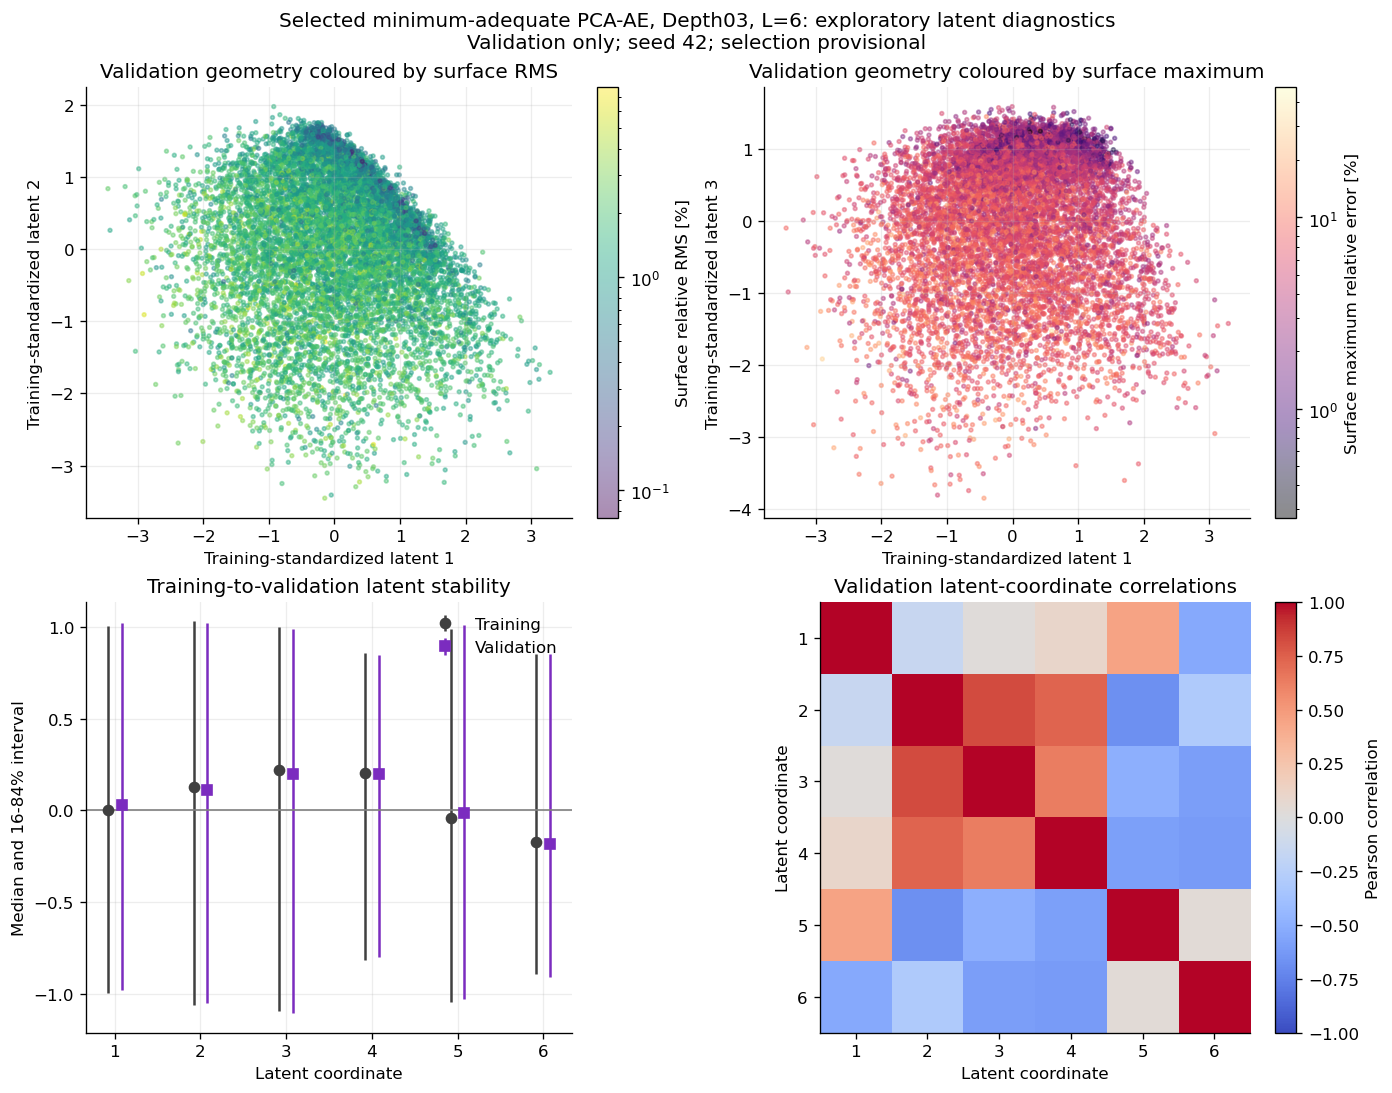

Collapsed latent coordinates: []


In [21]:
rms_percent = 100.0 * surface_rms
maximum_percent = 100.0 * surface_maximum
rms_norm = shared_positive_log_norm(
    (
        rms_percent,
        100.0 * counterpart_arrays["surface_relative_rmse"],
    )
)
surface_maximum_norm = shared_positive_log_norm(
    (
        maximum_percent,
        100.0 * counterpart_arrays["surface_relative_maximum"],
    )
)

figure, axes = plt.subplots(
    2,
    2,
    figsize=FIGURE_SIZES["latent_geometry"],
    constrained_layout=True,
)
rms_scatter = axes[0, 0].scatter(
    validation_standardized[:, first_coordinate],
    validation_standardized[:, second_coordinate],
    c=rms_percent,
    s=5,
    alpha=0.45,
    cmap="viridis",
    norm=rms_norm,
    rasterized=True,
)
maximum_scatter = axes[0, 1].scatter(
    validation_standardized[:, first_coordinate],
    validation_standardized[:, third_coordinate],
    c=maximum_percent,
    s=5,
    alpha=0.45,
    cmap="magma",
    norm=surface_maximum_norm,
    rasterized=True,
)
axes[0, 0].set(
    xlabel=f"Training-standardized latent {first_coordinate + 1}",
    ylabel=f"Training-standardized latent {second_coordinate + 1}",
    title="Validation geometry coloured by surface RMS",
)
axes[0, 1].set(
    xlabel=f"Training-standardized latent {first_coordinate + 1}",
    ylabel=f"Training-standardized latent {third_coordinate + 1}",
    title="Validation geometry coloured by surface maximum",
)
figure.colorbar(
    rms_scatter,
    ax=axes[0, 0],
    label="Surface relative RMS [%]",
)
figure.colorbar(
    maximum_scatter,
    ax=axes[0, 1],
    label="Surface maximum relative error [%]",
)

latent_dimension = validation_standardized.shape[1]
coordinate_numbers = np.arange(1, latent_dimension + 1)
train_quantiles = np.full((3, latent_dimension), np.nan)
validation_quantiles = np.full((3, latent_dimension), np.nan)
train_quantiles[:, valid_latent_coordinates] = np.quantile(
    train_standardized[:, valid_latent_coordinates],
    (0.16, 0.50, 0.84),
    axis=0,
)
validation_quantiles[:, valid_latent_coordinates] = np.quantile(
    validation_standardized[:, valid_latent_coordinates],
    (0.16, 0.50, 0.84),
    axis=0,
)
axes[1, 0].errorbar(
    coordinate_numbers - 0.08,
    train_quantiles[1],
    yerr=np.vstack(
        (
            train_quantiles[1] - train_quantiles[0],
            train_quantiles[2] - train_quantiles[1],
        )
    ),
    fmt="o",
    color="0.25",
    label="Training",
)
axes[1, 0].errorbar(
    coordinate_numbers + 0.08,
    validation_quantiles[1],
    yerr=np.vstack(
        (
            validation_quantiles[1] - validation_quantiles[0],
            validation_quantiles[2] - validation_quantiles[1],
        )
    ),
    fmt="s",
    color=selected_family_color,
    label="Validation",
)
axes[1, 0].axhline(0.0, color="0.5", linewidth=1.0)
axes[1, 0].set(
    xlabel="Latent coordinate",
    ylabel="Median and 16-84% interval",
    title="Training-to-validation latent stability",
    xticks=coordinate_numbers,
)
axes[1, 0].legend(frameon=False)

latent_correlations = np.full((latent_dimension, latent_dimension), np.nan)
valid_correlations = np.corrcoef(
    validation_standardized[:, valid_latent_coordinates],
    rowvar=False,
)
latent_correlations[np.ix_(valid_latent_coordinates, valid_latent_coordinates)] = (
    valid_correlations
)
latent_cmap = plt.get_cmap("coolwarm").copy()
latent_cmap.set_bad("lightgrey")
latent_image = axes[1, 1].imshow(
    np.ma.masked_invalid(latent_correlations),
    vmin=-1.0,
    vmax=1.0,
    cmap=latent_cmap,
    aspect="equal",
)
axes[1, 1].set(
    xlabel="Latent coordinate",
    ylabel="Latent coordinate",
    title="Validation latent-coordinate correlations",
    xticks=np.arange(latent_dimension),
    yticks=np.arange(latent_dimension),
    xticklabels=coordinate_numbers,
    yticklabels=coordinate_numbers,
)
axes[1, 1].grid(False)
figure.colorbar(latent_image, ax=axes[1, 1], label="Pearson correlation")
figure.suptitle(selected_figure_title("exploratory latent diagnostics"))
save_figure(figure, "PCA_AE_Selected_Latent_Geometry.pdf")

print("Collapsed latent coordinates:", collapsed_coordinates.tolist())


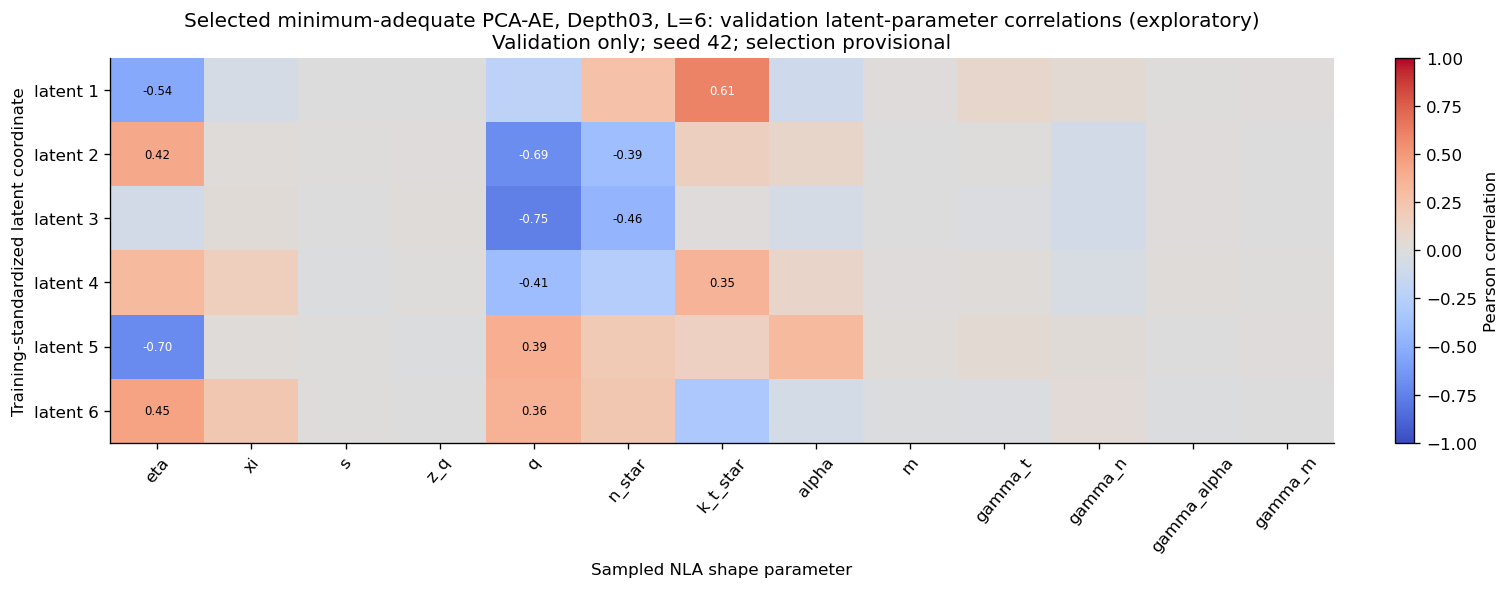

All validation latent-parameter correlations are defined.


In [22]:
def read_hdf5_rows(
    dataset,
    indices,
):
    """
    Read arbitrary unique HDF5 rows without accessing other split rows.
    
    Arguments:
        dataset (h5py.Dataset):
            Row-major source dataset.
        indices (numpy.ndarray):
            Unique source-row indices in requested output order.
    
    Returns:
        values (numpy.ndarray):
            Requested rows in the original index order.
    """
    indices = np.asarray(indices, dtype=np.int64)
    order = np.argsort(indices)
    sorted_indices = indices[order]
    if len(np.unique(sorted_indices)) != len(sorted_indices):
        raise ValueError("Source indices must be unique.")
    sorted_values = dataset[sorted_indices]
    values = np.empty_like(sorted_values)
    values[order] = sorted_values
    return values


with h5py.File(source_path, "r") as source_file:
    authoritative_train_indices = source_file["splits/train"][:]
    authoritative_validation_indices = source_file["splits/validation"][:]
    if not np.array_equal(train_source_indices, authoritative_train_indices):
        raise ValueError("Latent/source training indices are misaligned.")
    if not np.array_equal(
        validation_source_indices,
        authoritative_validation_indices,
    ):
        raise ValueError("Latent/source validation indices are misaligned.")
    parameter_values = read_hdf5_rows(
        source_file["parameters/values"],
        validation_source_indices,
    )
    parameter_names = [
        value.decode() if isinstance(value, bytes) else str(value)
        for value in source_file["parameters/names"][:]
    ]

if parameter_values.shape != (EXPECTED_VALIDATION_SAMPLES, 13):
    raise ValueError("Unexpected validation parameter shape.")

parameter_correlations = np.empty((latent_dimension, len(parameter_names)))
undefined_correlations = []
for latent_index in range(latent_dimension):
    for parameter_index, parameter_name in enumerate(parameter_names):
        value = safe_pearson_correlation(
            validation_standardized[:, latent_index],
            parameter_values[:, parameter_index],
        )
        parameter_correlations[latent_index, parameter_index] = value
        if not np.isfinite(value):
            undefined_correlations.append(
                (f"latent {latent_index + 1}", parameter_name)
            )

correlation_cmap = plt.get_cmap("coolwarm").copy()
correlation_cmap.set_bad("lightgrey")
figure, axis = plt.subplots(
    figsize=FIGURE_SIZES["latent_parameter_correlations"],
    constrained_layout=True,
)
correlation_image = axis.imshow(
    np.ma.masked_invalid(parameter_correlations),
    aspect="auto",
    cmap=correlation_cmap,
    vmin=-1.0,
    vmax=1.0,
)
axis.set(
    xlabel="Sampled NLA shape parameter",
    ylabel="Training-standardized latent coordinate",
    title=selected_figure_title(
        "validation latent-parameter correlations (exploratory)"
    ),
    xticks=np.arange(len(parameter_names)),
    yticks=np.arange(latent_dimension),
    xticklabels=parameter_names,
    yticklabels=[
        f"latent {index + 1}" for index in range(latent_dimension)
    ],
)
axis.tick_params(axis="x", rotation=50)
axis.grid(False)
for row in range(latent_dimension):
    for column in range(len(parameter_names)):
        value = parameter_correlations[row, column]
        if np.isfinite(value) and abs(value) >= 0.35:
            axis.text(
                column,
                row,
                f"{value:.2f}",
                ha="center",
                va="center",
                color="white" if abs(value) >= 0.55 else "black",
                fontsize=7,
            )
figure.colorbar(
    correlation_image,
    ax=axis,
    label="Pearson correlation",
)
save_figure(
    figure,
    "PCA_AE_Selected_Latent_Parameter_Correlations.pdf",
)

if undefined_correlations:
    print("Undefined constant-input correlations:")
    for latent_name, parameter_name in undefined_correlations:
        print(f"  {latent_name} versus {parameter_name}")
else:
    print("All validation latent-parameter correlations are defined.")


## 11. Method-specific findings and boundary

The statements below are generated from the authenticated validation snapshot. They summarize PCA-AE only and deliberately avoid selecting a cross-family winner.


In [23]:
outperformance_count = sum(
    bool(result["autoencoder_outperforms_pca"])
    for result in CELL_RESULTS.values()
)
first_qualified = {}
available_by_depth = {}
for depth in DEPTHS:
    available = [
        latent_dim
        for latent_dim in LATENT_DIMENSIONS
        if (depth, latent_dim) in CELL_RESULTS
    ]
    available_by_depth[depth] = available
    qualified = [
        latent_dim
        for latent_dim in available
        if CELL_RESULTS[(depth, latent_dim)]["variance_recovered"]
        >= TARGET_VARIANCE_RECOVERED
    ]
    first_qualified[depth] = min(qualified) if qualified else None

cap_limited_labels = [
    f"{depth}/Latent{latent_dim:02d}"
    for depth, latent_dim in sorted(CONVERGENCE)
    if CONVERGENCE[(depth, latent_dim)]["cap_limited"]
]
seed_values = {
    int(data["config"].training.seed)
    for data in RUN_DATA.values()
}
deterministic_values = {
    bool(data["config"].training.deterministic)
    for data in RUN_DATA.values()
}

finding_lines = [
    (
        "- Analysis-ready PCA-AE configurations: "
        f"**{len(RUN_DATA)}/{len(EXPECTED_PCA_CELL_IDS)}**."
    ),
    f"- Minimum adequate PCA-AE: **{minimum_adequate_cell_id}**.",
    f"- Best observed PCA-AE validation accuracy: **{best_accuracy_cell_id}**.",
    f"- Detailed diagnostic representative: **{diagnostic_cell_id}**.",
    (
        "- Available configurations satisfying the official matched-PCA "
        "variance/log-MSE outcome: "
        f"**{outperformance_count}/{len(CELL_RESULTS)}**."
    ),
]
for depth in DEPTHS:
    available = available_by_depth[depth]
    value = first_qualified[depth]
    if not available:
        finding_lines.append(f"- {depth}: **no eligible configurations**.")
        continue
    finding_lines.append(
        f"- {depth}: available sampled dimensions are **{available}**; "
        f"the first available dimension reaching "
        f"{TARGET_VARIANCE_RECOVERED:.3f} variance recovery is "
        + (f"**{value}**." if value is not None else "not present.")
    )
finding_lines.extend(
    [
        (
            "- Epoch-ceiling-limited available runs: **"
            + (", ".join(cap_limited_labels) if cap_limited_labels else "none")
            + "**."
        ),
        (
            "- Replicate coverage among available configurations: "
            f"{min(result['n_runs'] for result in CELL_RESULTS.values())}-"
            f"{max(result['n_runs'] for result in CELL_RESULTS.values())} run(s) "
            "and "
            f"{min(result['n_seeds'] for result in CELL_RESULTS.values())}-"
            f"{max(result['n_seeds'] for result in CELL_RESULTS.values())} seed(s); "
            f"representative seeds are {sorted(seed_values)} and deterministic "
            f"flags are {sorted(deterministic_values)}."
        ),
        (
            "- Unavailable nonselected cells are shown explicitly and are "
            "excluded without interpolation or imputation."
        ),
    ]
)
display(Markdown("\n".join(finding_lines)))


- Analysis-ready PCA-AE configurations: **15/15**.
- Minimum adequate PCA-AE: **PCA_AE:PCA_AE:Depth03:L06**.
- Best observed PCA-AE validation accuracy: **PCA_AE:PCA_AE:Depth03:L10**.
- Detailed diagnostic representative: **PCA_AE:PCA_AE:Depth03:L06**.
- Available configurations satisfying the official matched-PCA variance/log-MSE outcome: **15/15**.
- Depth03: available sampled dimensions are **[2, 4, 6, 8, 10]**; the first available dimension reaching 0.999 variance recovery is **6**.
- Depth04: available sampled dimensions are **[2, 4, 6, 8, 10]**; the first available dimension reaching 0.999 variance recovery is **6**.
- Depth05: available sampled dimensions are **[2, 4, 6, 8, 10]**; the first available dimension reaching 0.999 variance recovery is **6**.
- Epoch-ceiling-limited available runs: **Depth03/Latent10**.
- Replicate coverage among available configurations: 1-1 run(s) and 1-1 seed(s); representative seeds are [42] and deterministic flags are [False].
- Unavailable nonselected cells are shown explicitly and are excluded without interpolation or imputation.

## Final validation-only boundary

This notebook stops at method-specific validation analysis. Final cross-family selection, freezing, one-time test evaluation, and promoted latent export remain controlled by `ModelSelection.ipynb`.


In [24]:
assert RUN_DATA
assert set(RUN_DATA) <= {
    (depth, latent_dim)
    for depth in DEPTHS
    for latent_dim in LATENT_DIMENSIONS
}
assert set(CELL_RESULTS) == set(RUN_DATA)
assert len({data["run_directory"] for data in RUN_DATA.values()}) == len(
    RUN_DATA
)
assert minimum_adequate_key in RUN_DATA
assert best_accuracy_key in RUN_DATA
assert selected_diagnostic_key in RUN_DATA
assert seed_values
assert deterministic_values <= {False, True}
assert current_audit_table_rows == AUDIT_TABLE_ROWS
assert current_selection_input_sha256 == manifest_inputs[
    "selection_input_sha256"
]
assert selected_diagnostic_run["cell_id"] == diagnostic_cell_id
assert selected_diagnostic_directory == RUN_DATA[selected_diagnostic_key][
    "run_directory"
]
assert test_gate["selection_frozen"] is False
assert test_gate["test_evaluation_allowed"] is False
assert all(
    int(data["metrics"]["number_of_surfaces"])
    == EXPECTED_VALIDATION_SAMPLES
    for data in RUN_DATA.values()
)
assert all(
    data["summary"]["test_split_used_during_training"] is False
    for data in RUN_DATA.values()
)
assert exported_splits == ["train", "validation"]
assert len(train_latent) == EXPECTED_TRAINING_SAMPLES
assert len(validation_latent) == EXPECTED_VALIDATION_SAMPLES
assert selected_diagnostic_key[0] in DEPTH_SENSITIVITY_DIAGNOSTICS

expected_figure_names = {
    "PCA_AE_Validation_Accuracy.pdf",
    "PCA_AE_Validation_Tails.pdf",
    "PCA_AE_Error_Decomposition.pdf",
    "PCA_AE_Selected_Training_History.pdf",
    "PCA_AE_Selected_Validation_Diagnostics.pdf",
    "PCA_AE_Selected_Depth_Sensitivity.pdf",
    "PCA_AE_Selected_Worst_Reconstructions.pdf",
    "PCA_AE_Selected_Latent_Geometry.pdf",
    "PCA_AE_Selected_Latent_Parameter_Correlations.pdf",
}
assert {path.name for path in GENERATED_FIGURES} == expected_figure_names
assert all(
    path.is_file() and path.stat().st_size > 0
    for path in GENERATED_FIGURES
)

print("PCA-AE notebook validation passed.")
print("Generated figures:")
for path in GENERATED_FIGURES:
    print(" ", path.relative_to(PROJECT_ROOT))


PCA-AE notebook validation passed.
Generated figures:
  Figure/NLA/PCA_AE/PCA_AE_Validation_Accuracy.pdf
  Figure/NLA/PCA_AE/PCA_AE_Validation_Tails.pdf
  Figure/NLA/PCA_AE/PCA_AE_Error_Decomposition.pdf
  Figure/NLA/PCA_AE/PCA_AE_Selected_Training_History.pdf
  Figure/NLA/PCA_AE/PCA_AE_Selected_Validation_Diagnostics.pdf
  Figure/NLA/PCA_AE/PCA_AE_Selected_Depth_Sensitivity.pdf
  Figure/NLA/PCA_AE/PCA_AE_Selected_Worst_Reconstructions.pdf
  Figure/NLA/PCA_AE/PCA_AE_Selected_Latent_Geometry.pdf
  Figure/NLA/PCA_AE/PCA_AE_Selected_Latent_Parameter_Correlations.pdf
